# Electricity model — monthly BVAR-SV-outlier with seasonal dummies


This notebook estimates the electricity component of the energy-inflation suite. The endogenous block contains monthly absolute changes in wholesale natural-gas prices and pre-tax consumer electricity prices. Eleven calendar-month dummies enter as deterministic regressors; January is the omitted reference month because the model also contains a constant.

## 1. Imports and configuration


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    required_modules = (
        "energy_bvar_model.py",
        "energy_bvar_electricity.py",
        "energy_bvar_plot.py",
        "energy_bvar_io.py",
    )
    if all((candidate / name).exists() for name in required_modules):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place energy_bvar_model.py, energy_bvar_electricity.py, "
        "energy_bvar_plot.py and energy_bvar_io.py beside this notebook "
        "or in src/model/."
    )

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    forecast_horizon_table,
    historical_decomposition,
    impulse_responses,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    path_horizon_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    prepare_bvar_panel,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)
from energy_bvar_io import (
    save_energy_bvar_result,
    save_energy_bvar_forecast_for_result,
)
from energy_bvar_electricity import (
    electricity_series_construction_table,
    forecast_to_hicp_electricity,
    load_electricity_panel,
    load_electricity_tax_context,
    make_electricity_seasonal_dummies,
    validate_electricity_tax_round_trip,
)
from energy_bvar_plot import (
    format_number,
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_fevd,
    plot_forecast_comparison,
    plot_hicp_forecast_fan,
    tax_inflation_spread_table,
    tax_scenario_effect_summary_table,
    plot_tax_assumptions,
    plot_tax_scenario_impact,
    plot_tax_level_and_inflation_impact,
    plot_historical_decomposition,
    plot_impulse_responses,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    plot_volatility_decomposition,
    style_numeric_table,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

SEED = 42
P = 12
MISSING_DATA_METHOD = "linear"  # "linear" = fast approximation; "dk" = exact interior-missing treatment
SIMULATE_FUTURE_OUTLIERS = True
CODE_VERSION = "energy_bvar_model-v2"
REFERENCE_MONTH = 1
EXOG_PRIOR_SCALE = 10.0
VARIABLES = ["natural_gas_wholesale", "electricity_pre_tax"]
UNITS = {
    "natural_gas_wholesale": "EUR/MWh",
    "electricity_pre_tax": "EUR/kWh",
}
SAVE_RESULTS = False      # heavy Gibbs cache
SAVE_FORECASTS = True     # lightweight predictive store for Notebook 10
RESULTS_ROOT = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")

Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model


## 2. Data and deterministic regressors


### Missing-data treatment used in this notebook

`MISSING_DATA_METHOD = "linear"` is the fast default. Bounded interior missing **levels** are interpolated once; these pseudo-observations then enter the likelihood as fixed values. Set `MISSING_DATA_METHOD = "dk"` to propagate uncertainty about interior gaps through the Gibbs sampler. In both modes, the ragged edge and future conditional paths are handled by Durbin–Koopman state-space simulation. The result metadata and forecast-table/plot labels surface whether an approximation was actually used.


Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260808\electricity_monthly.csv
Sample calendar: 2003-07-01 to 2026-08-01
Seasonal reference month: 01


,series_type,model_unit,source_inputs,construction,note
natural_gas_wholesale,chain-linked wholesale price,EUR/MWh,"Bloomberg TTF; World Bank Natural gas, Europe; EUR/USD","Bloomberg TTF monthly mean; pre-TTF months are backcast with World Bank Natural gas, Europe via backward chain-linking.",Wholesale natural gas is the upstream explanatory variable.
electricity_pre_tax,constructed pre-tax price,EUR/kWh,"Haver HICP electricity; Eurostat after-tax price, VAT and excise",pre_tax_EUR_kWh = gamma_EUR_kWh * HICP / (1 + VAT/100) - EXC_EUR_kWh,Semiannual VAT and excise observations are held for six months and the final published values are carried through the edge. Estimated gamma: 0.00322579.


,natural_gas_wholesale,electricity_pre_tax
date,,
2025-09-01,32.02,0.23
2025-10-01,32.04,0.23
2025-11-01,30.66,0.23
2025-12-01,27.42,0.23
2026-01-01,34.52,0.23
2026-02-01,32.51,0.23
2026-03-01,52.63,0.23
2026-04-01,45.26,0.23
2026-05-01,47.34,0.23


,month_02,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11,month_12
date,,,,,,,,,,,
2025-09-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2025-10-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
2025-11-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
2025-12-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2026-01-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-03-01,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-04-01,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-05-01,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


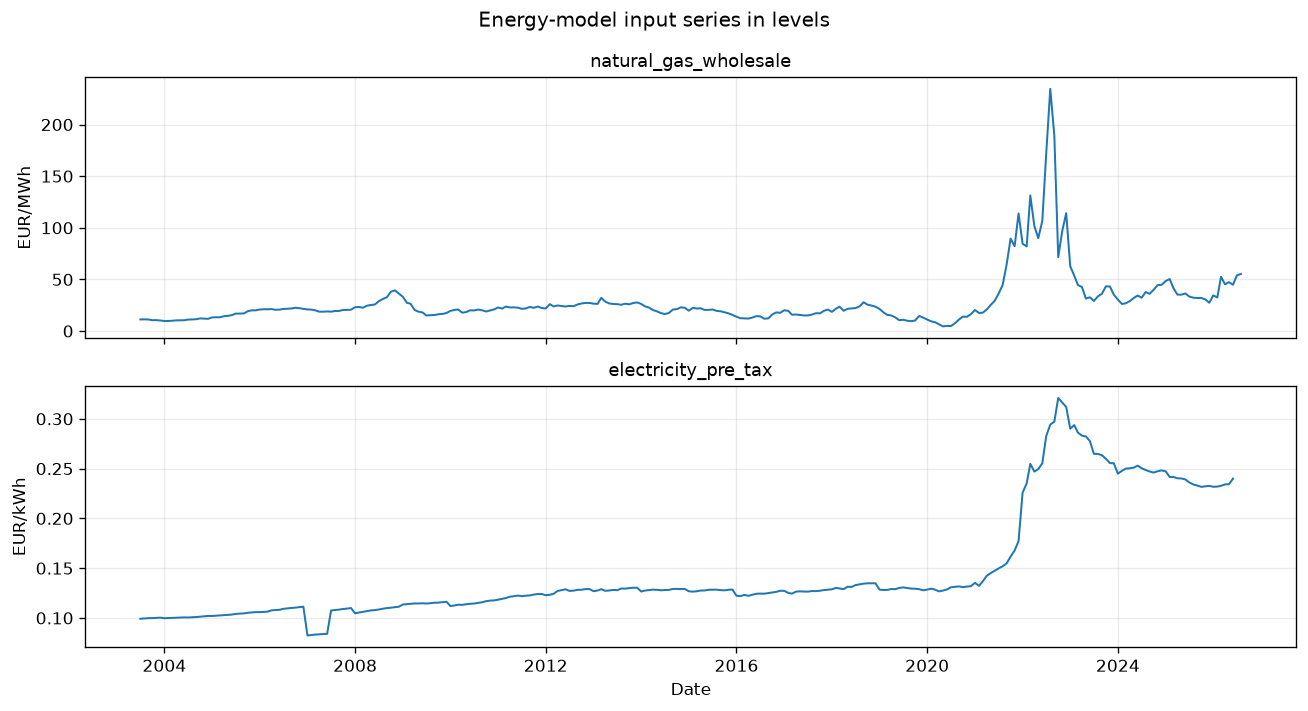

In [2]:
# Set VINTAGE = "YYYYMMDD" to force one processed vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path for path in PROCESSED_ROOT.glob("*/electricity_monthly.csv")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No electricity_monthly.csv found below {PROCESSED_ROOT}."
        )
    ELECTRICITY_DATASET = candidates[-1]
else:
    ELECTRICITY_DATASET = PROCESSED_ROOT / VINTAGE / "electricity_monthly.csv"

levels = load_electricity_panel(ELECTRICITY_DATASET, variables=VARIABLES)
seasonal_dummies = make_electricity_seasonal_dummies(
    levels.index,
    reference_month=REFERENCE_MONTH,
)

print(f"Dataset: {ELECTRICITY_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")
print(f"Seasonal reference month: {REFERENCE_MONTH:02d}")

display(style_numeric_table(
    electricity_series_construction_table(ELECTRICITY_DATASET),
    caption="Construction of the electricity-model level series",
))
display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed levels",
))
display(style_numeric_table(
    seasonal_dummies.tail(12),
    caption="Known calendar-month deterministic regressors",
))
plot_data_levels(levels, units=UNITS)
plt.show()

### Absolute monthly changes

The endogenous vector is

$$
y_t =
\begin{bmatrix}
\Delta P_t^{\mathrm{gas}} \\
\Delta P_t^{\mathrm{electricity,pre-tax}}
\end{bmatrix},
\qquad
\Delta P_t=P_t-P_{t-1}.
$$

Seasonal dummies are **not differenced**. They are deterministic indicators attached to the current calendar month.


,value
missing_data_method,linear
missing_treatment_exact,True
interpolated_level_cells,0
balanced_change_start,2003-08-01 00:00:00
balanced_change_end,2026-06-01 00:00:00
balanced_changes,275
VAR_regression_observations,263
seasonal_regressors,11
regression_columns_per_equation,36
ragged_edge_months,2


,natural_gas_wholesale,electricity_pre_tax
date,,
2026-07-01,9.11,—
2026-08-01,1.33,—


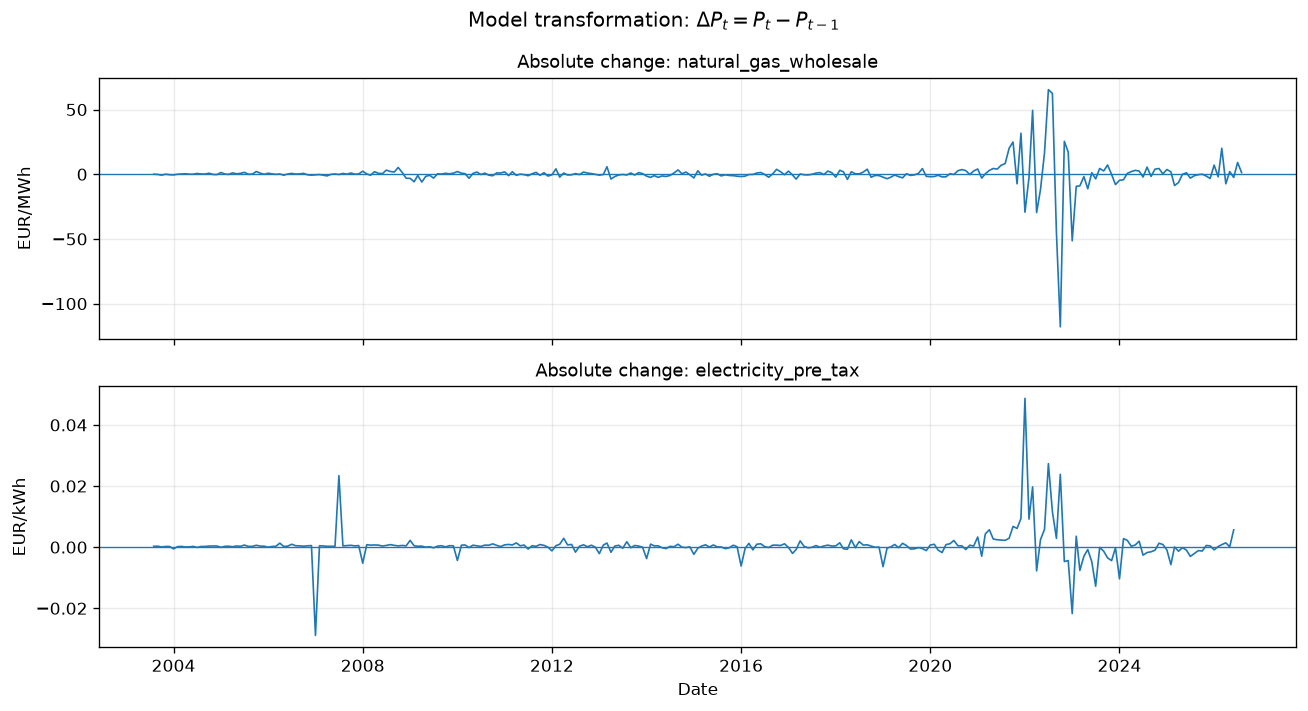

In [3]:
prep = prepare_bvar_panel(
    levels,
    p=P,
    variables=VARIABLES,
    exog=seasonal_dummies,
    missing_data_method=MISSING_DATA_METHOD,
)

transformation_summary = pd.Series({
    "missing_data_method": prep["missing_data_method"],
    "missing_treatment_exact": prep["missing_treatment_exact"],
    "interpolated_level_cells": prep["n_interpolated_level_cells"],
    "balanced_change_start": prep["balanced_start"],
    "balanced_change_end": prep["balanced_end"],
    "balanced_changes": prep["n_balanced_changes"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "seasonal_regressors": prep["n_exog"],
    "regression_columns_per_equation": prep["k"],
    "ragged_edge_months": prep["n_ragged_months"],
    "latest_calendar_month": prep["last_calendar_date"],
})
display(style_numeric_table(
    transformation_summary.to_frame("value"),
    caption="Transformation, deterministic block and sample",
))
display(style_numeric_table(
    prep["ragged"],
    caption="Ragged-edge absolute changes",
))

if prep.get("n_interpolated_level_cells", 0):
    linear_imputation = (
        prep["levels"]
        .where(prep["interpolated_level_mask"])
        .stack()
        .rename("linear_imputation")
        .to_frame()
    )
    linear_imputation.index.names = ["date", "variable"]
    display(style_numeric_table(
        linear_imputation.head(30),
        caption="Linear interpolation audit — first imputed interior levels",
    ))

plot_absolute_differences(prep["differences"], units=UNITS)
plt.show()

## 3. Model

For $t=1,\ldots,T$, the model is

$$
y_t = c + \sum_{\ell=1}^{12} B_\ell y_{t-\ell} + D s_t + \nu_t,
$$

where $s_t$ contains eleven monthly dummies. With January omitted, the constant is the January deterministic baseline and each coefficient in $D$ measures the difference relative to January.

The residual covariance follows

$$
\nu_t=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t,
\qquad \varepsilon_t\sim\mathcal N(0,I),
$$

with random-walk log volatilities and model-based transitory outlier scales.


## 4. Priors


,value,interpretation
lambda1,0.20,overall Minnesota lag tightness
lambda2,0.50,additional cross-lag tightness
lambda3,1.00,lag-decay exponent
lambda4,10.00,constant prior scale
exog_prior_scale,10.00,seasonal coefficient prior scale
A prior variance,10.00,variance of the free contemporaneous A coefficient
phi prior mean,0.02,prior mean of volatility-of-volatility variance
outlier alpha,2.50,Beta outlier pseudo-count
outlier beta,117.50,Beta regular-observation pseudo-count


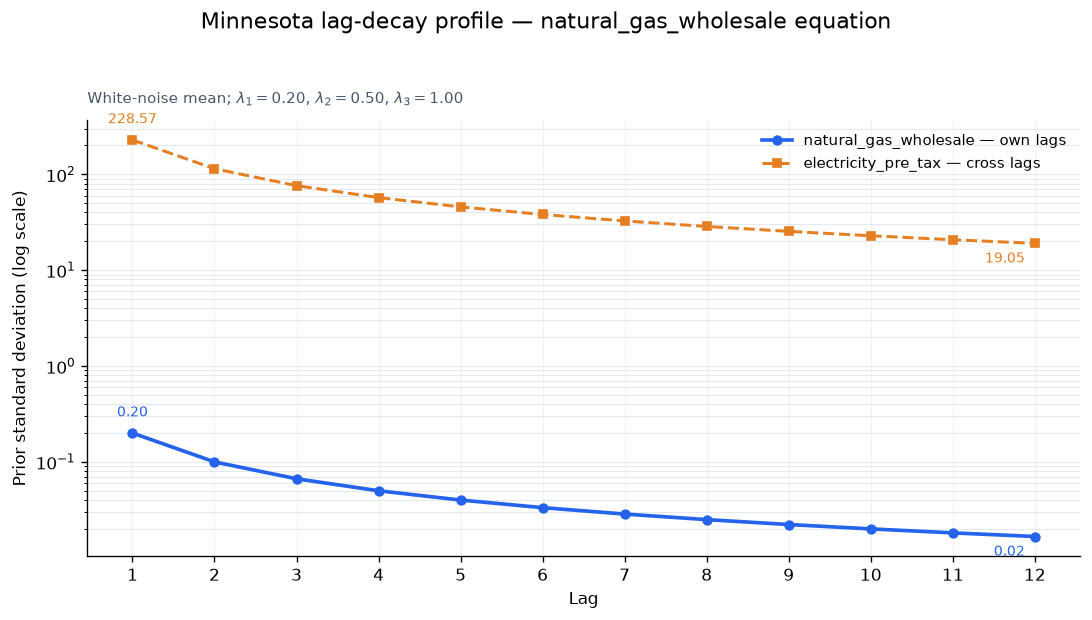

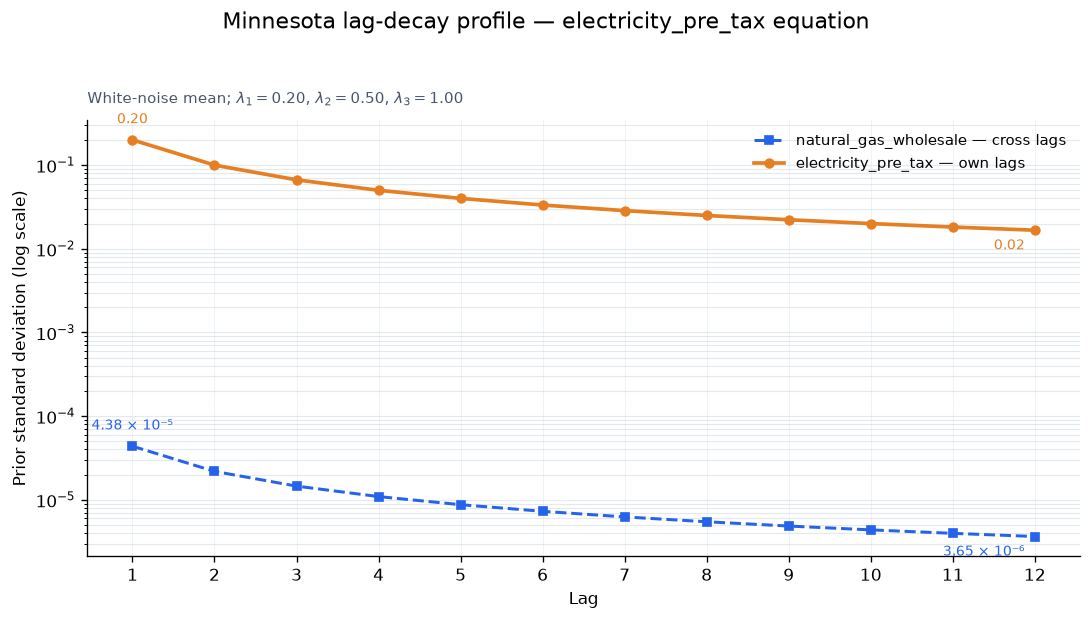

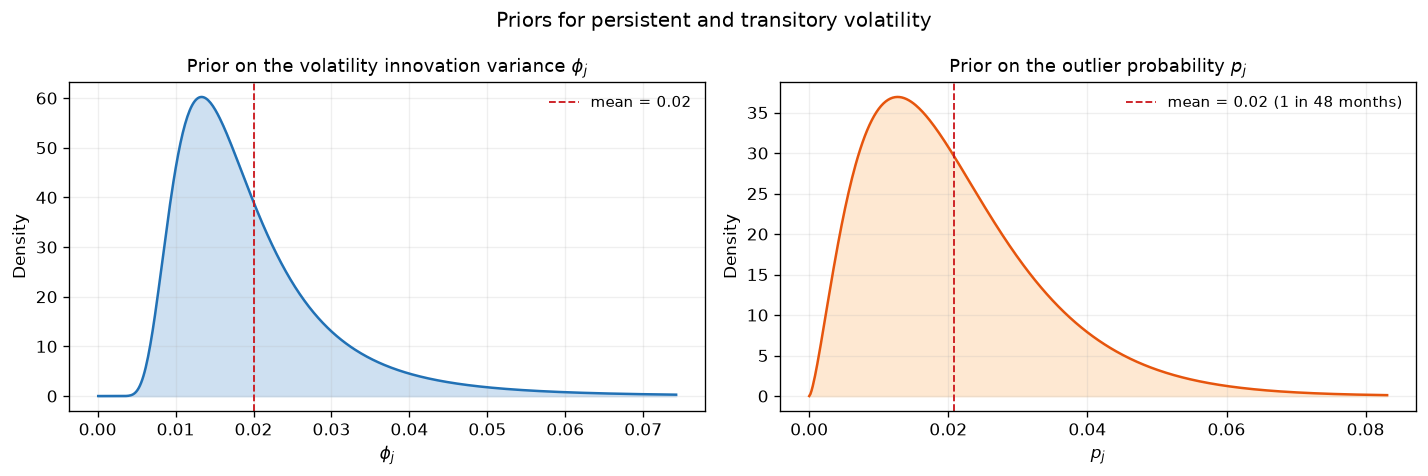

In [4]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(
    prep,
    prior_config,
    exog_prior_scale=EXOG_PRIOR_SCALE,
)

prior_table = pd.DataFrame({
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
        EXOG_PRIOR_SCALE,
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
    ],
    "interpretation": [
        "overall Minnesota lag tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
        "seasonal coefficient prior scale",
        "variance of the free contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta outlier pseudo-count",
        "Beta regular-observation pseudo-count",
    ],
}, index=[
    "lambda1", "lambda2", "lambda3", "lambda4",
    "exog_prior_scale", "A prior variance", "phi prior mean",
    "outlier alpha", "outlier beta",
])
display(style_numeric_table(prior_table, caption="Prior hyperparameters"))

prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)
plot_phi_and_outlier_priors(prior)
plt.show()

## 5. Posterior and Gibbs sampler

The coefficient draw treats the constant, lag coefficients and seasonal coefficients as one Gaussian regression block. Stability truncation applies only to the autoregressive lag block; deterministic coefficients do not enter the companion roots. The SV block jointly updates the complete volatility path and its innovation variance using the centered KSC sampler.


In [5]:
sampler_config = SamplerConfig(
    reps=6_000,
    burn=3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=500,
)

result = run_energy_bvar(
    levels=levels,
    model_id="electricity",
    vintage=ELECTRICITY_DATASET.parent.name,
    p=P,
    variables=VARIABLES,
    exog=seasonal_dummies,
    exog_prior_scale=EXOG_PRIOR_SCALE,
    prior_config=prior_config,
    sampler_config=sampler_config,
    missing_data_method=MISSING_DATA_METHOD,
    code_version=CODE_VERSION,
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"Run ID: {result['metadata']['run_id']}")
print(f"Missing-data method: {result['metadata']['missing_data_method']}")
print(f"Exact missing-data treatment: {result['metadata']['missing_treatment_exact']}")
print(f"Interpolated level cells: {result['metadata']['interpolated_level_cells']}")
print(f"B instability proposal rejection rate: {result['B_instability_rejection_rate']:.2%}")
print(f"Deterministic regressors: {result['exog_names']}")
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

if SAVE_RESULTS:
    saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
    print(f"Saved run: {saved_result_paths['directory']}")

iteration 500/6,000 | B instability rejection 0.00% | radius 0.7752
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8164
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.7488
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.7989
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.7765
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.8074
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.7926
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8090
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.7331
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.8013
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.7358
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.7819
Retained posterior draws: 3,000
Run ID: c3570860c0c138880504601e18237299724afdd2698d4ef31f4181ead5b8d22d
Missing-data method: linear
Exact missing-data treatment:

,KSC offset
natural_gas_wholesale,6.78 × 10⁻⁶
electricity_pre_tax,1.13 × 10⁻¹²


## 6. Results


### 6.1 Posterior coefficients, including seasonal effects



natural_gas_wholesale equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,115.39,0.19,0.19,0.35,-0.40,-0.17,0.54,0.75,387.57
natural_gas_wholesale L1,0.00,0.20,0.10,0.10,0.07,-0.02,0.03,0.17,0.22,486.03
electricity_pre_tax L1,0.00,228.57,14.44,13.22,23.67,-21.54,-7.42,34.95,55.33,1171.81
natural_gas_wholesale L2,0.00,0.10,0.03,0.04,0.06,-0.06,-0.02,0.09,0.13,677.72
electricity_pre_tax L2,0.00,114.28,5.58,5.91,21.34,-29.66,-14.11,25.05,40.38,1825.56
natural_gas_wholesale L3,0.00,0.07,0.08,0.08,0.05,5.78 × 10⁻³,0.03,0.13,0.16,614.63
electricity_pre_tax L3,0.00,76.19,27.58,28.95,21.86,-10.39,6.87,48.13,61.48,1195.27
natural_gas_wholesale L4,0.00,0.05,8.21 × 10⁻³,8.72 × 10⁻³,0.04,-0.06,-0.03,0.05,0.07,2072.25
electricity_pre_tax L4,0.00,57.14,-15.35,-15.94,20.64,-47.72,-34.27,3.78,19.14,1677.47


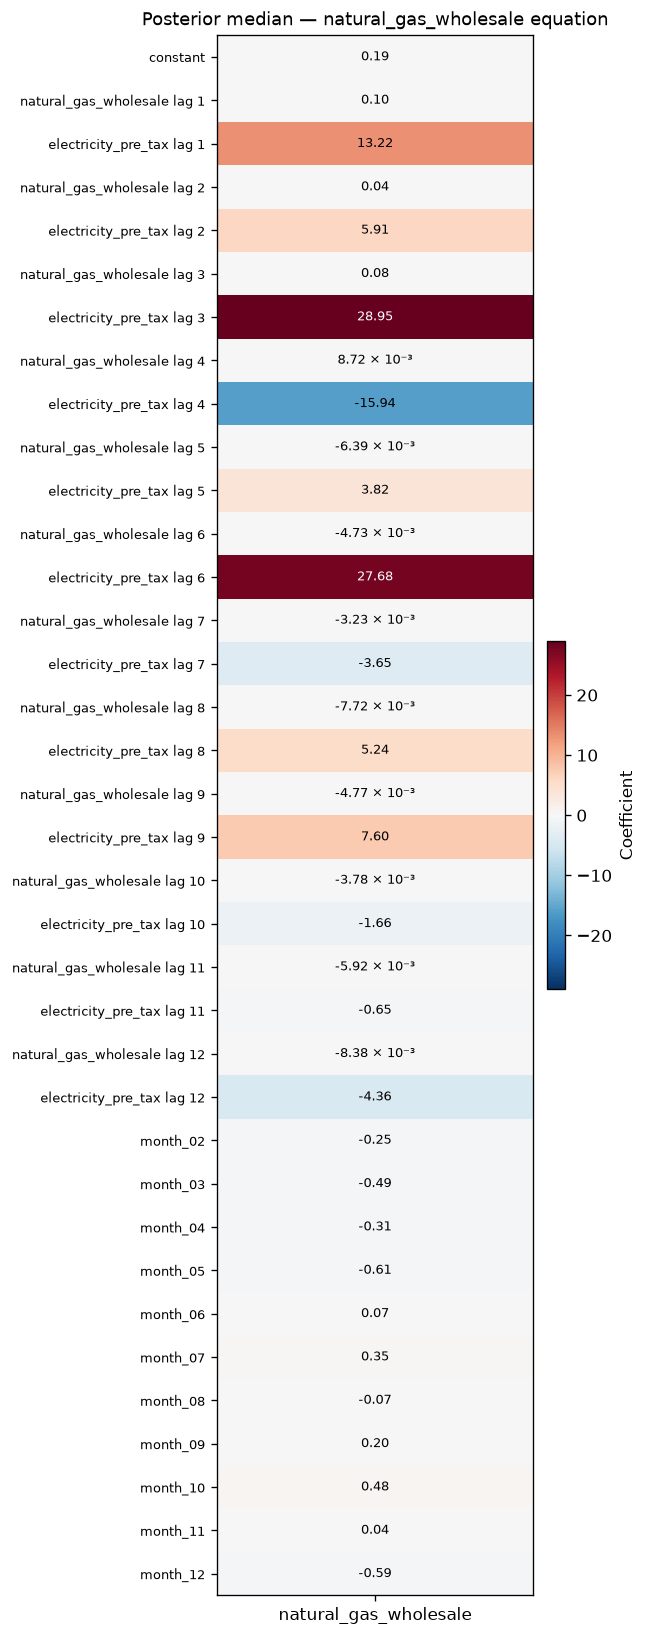

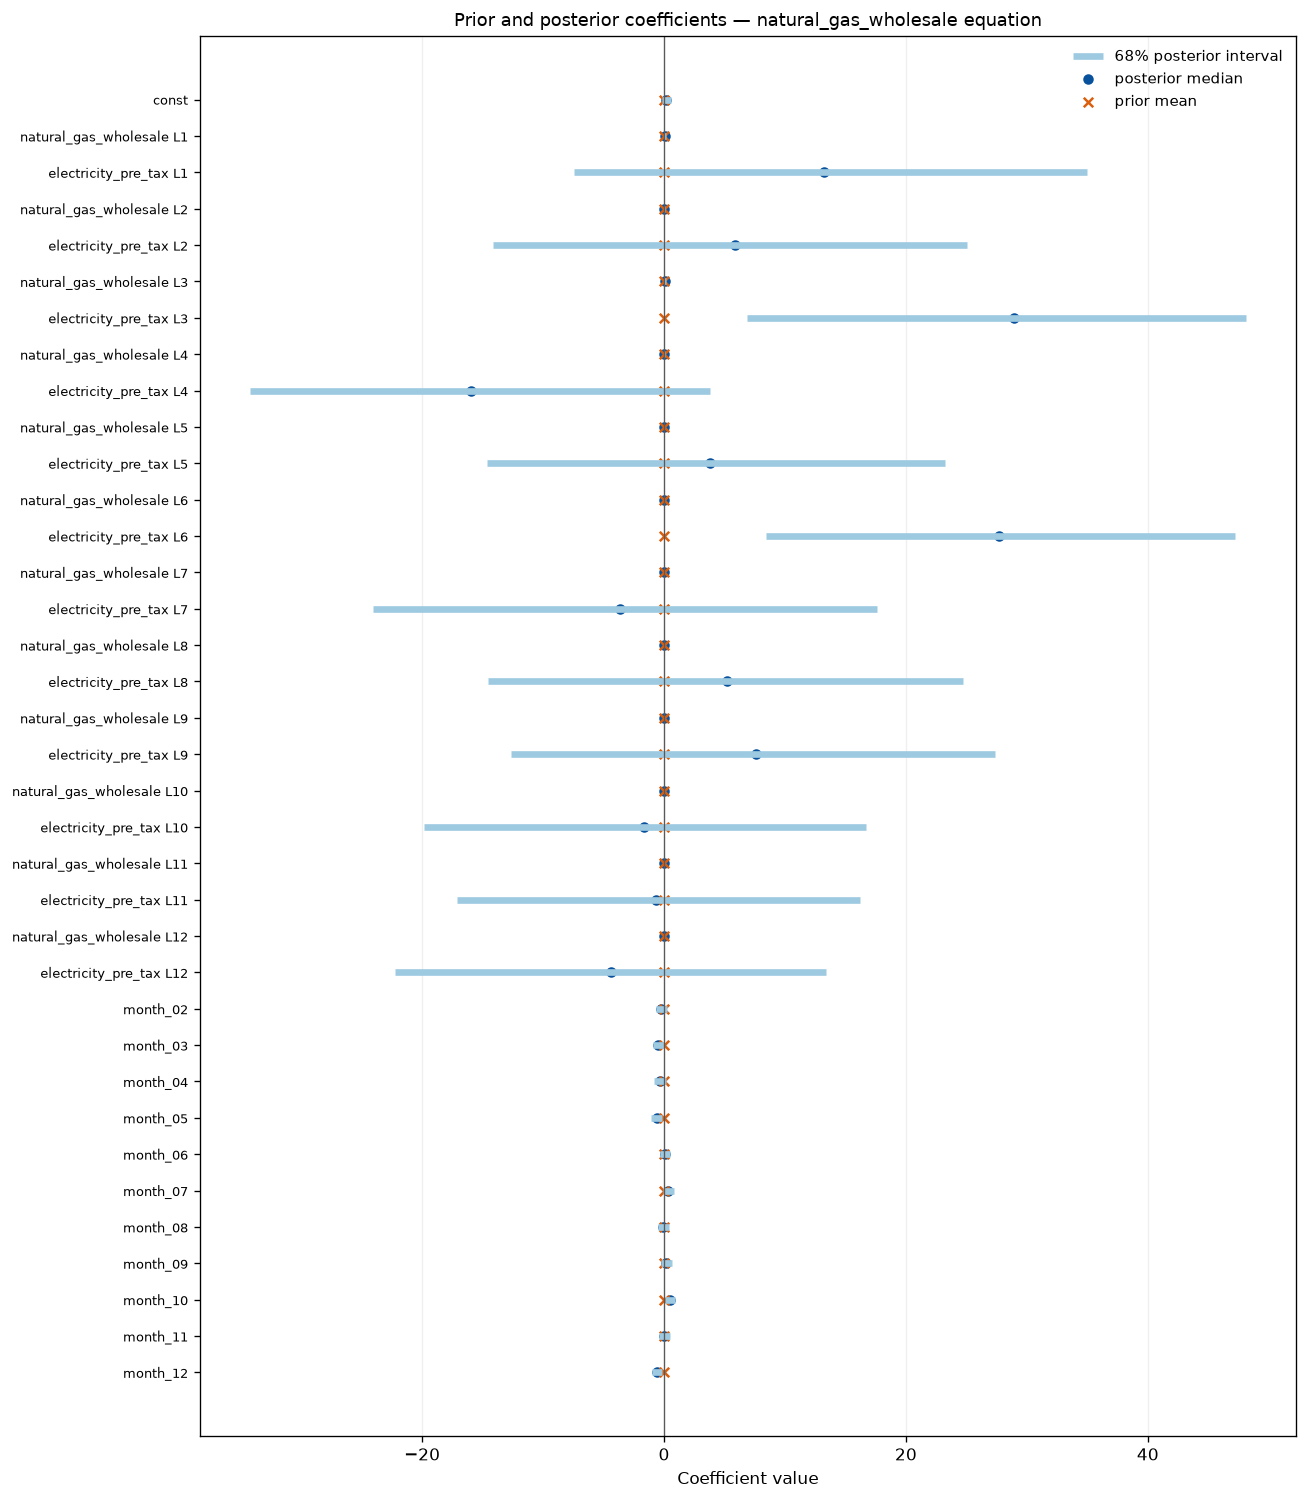


electricity_pre_tax equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,0.05,-2.66 × 10⁻⁴,-2.50 × 10⁻⁴,1.71 × 10⁻⁴,-5.77 × 10⁻⁴,-4.27 × 10⁻⁴,-1.10 × 10⁻⁴,-1.09 × 10⁻⁵,627.20
natural_gas_wholesale L1,0.00,4.38 × 10⁻⁵,1.18 × 10⁻⁵,1.29 × 10⁻⁵,2.02 × 10⁻⁵,-2.29 × 10⁻⁵,-8.87 × 10⁻⁶,3.24 × 10⁻⁵,4.31 × 10⁻⁵,171.13
electricity_pre_tax L1,0.00,0.20,0.02,0.01,0.02,-0.01,-2.14 × 10⁻³,0.03,0.05,1604.63
natural_gas_wholesale L2,0.00,2.19 × 10⁻⁵,1.50 × 10⁻⁵,1.47 × 10⁻⁵,1.52 × 10⁻⁵,-9.12 × 10⁻⁶,-1.93 × 10⁻⁷,3.06 × 10⁻⁵,4.03 × 10⁻⁵,448.18
electricity_pre_tax L2,0.00,0.10,5.19 × 10⁻³,5.24 × 10⁻³,0.02,-0.02,-0.01,0.02,0.03,2193.80
natural_gas_wholesale L3,0.00,1.46 × 10⁻⁵,2.35 × 10⁻⁵,2.35 × 10⁻⁵,1.25 × 10⁻⁵,2.83 × 10⁻⁶,1.09 × 10⁻⁵,3.64 × 10⁻⁵,4.37 × 10⁻⁵,1426.02
electricity_pre_tax L3,0.00,0.07,0.03,0.03,0.02,1.03 × 10⁻³,0.01,0.04,0.06,872.45
natural_gas_wholesale L4,0.00,1.09 × 10⁻⁵,-1.54 × 10⁻⁶,-1.47 × 10⁻⁶,9.71 × 10⁻⁶,-1.74 × 10⁻⁵,-1.13 × 10⁻⁵,8.28 × 10⁻⁶,1.42 × 10⁻⁵,488.05
electricity_pre_tax L4,0.00,0.05,3.11 × 10⁻³,3.05 × 10⁻³,0.01,-0.02,-0.01,0.02,0.03,2674.06


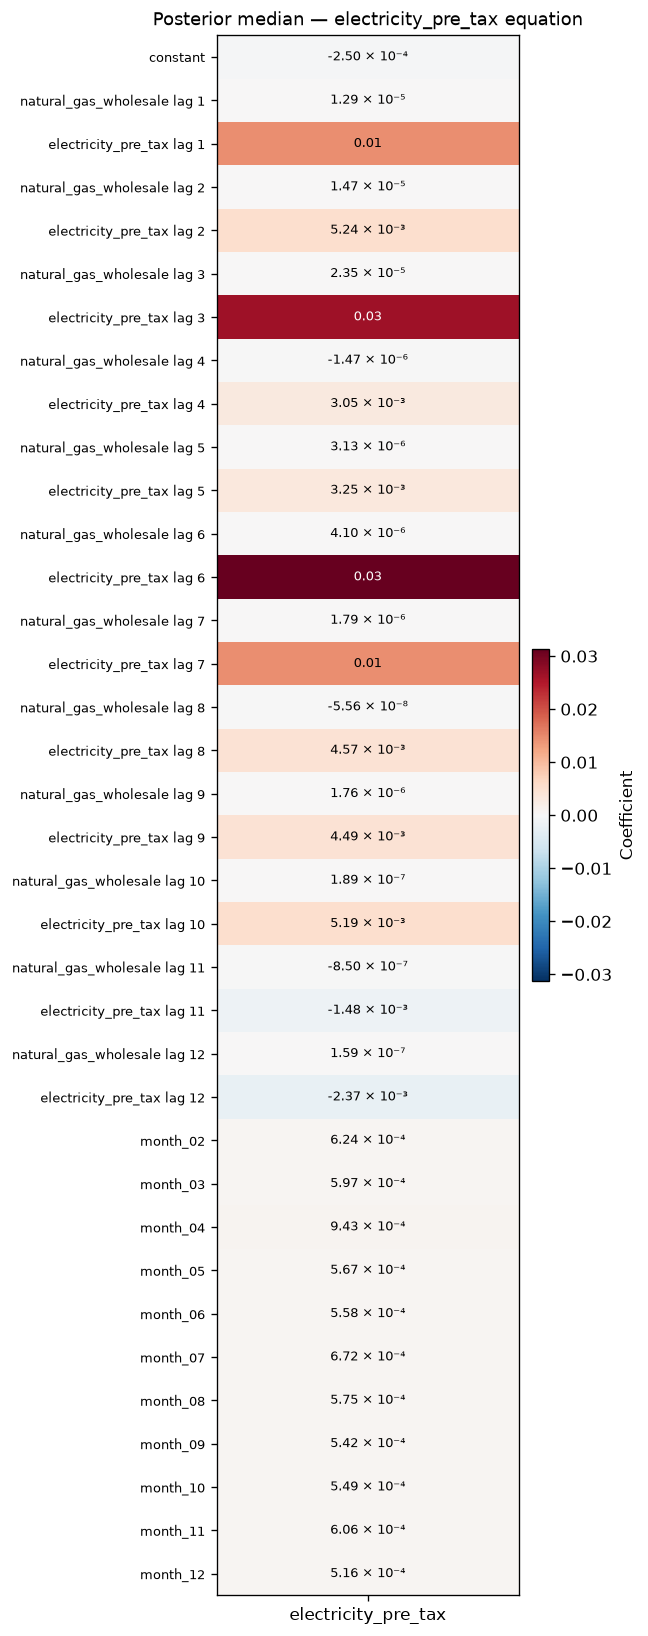

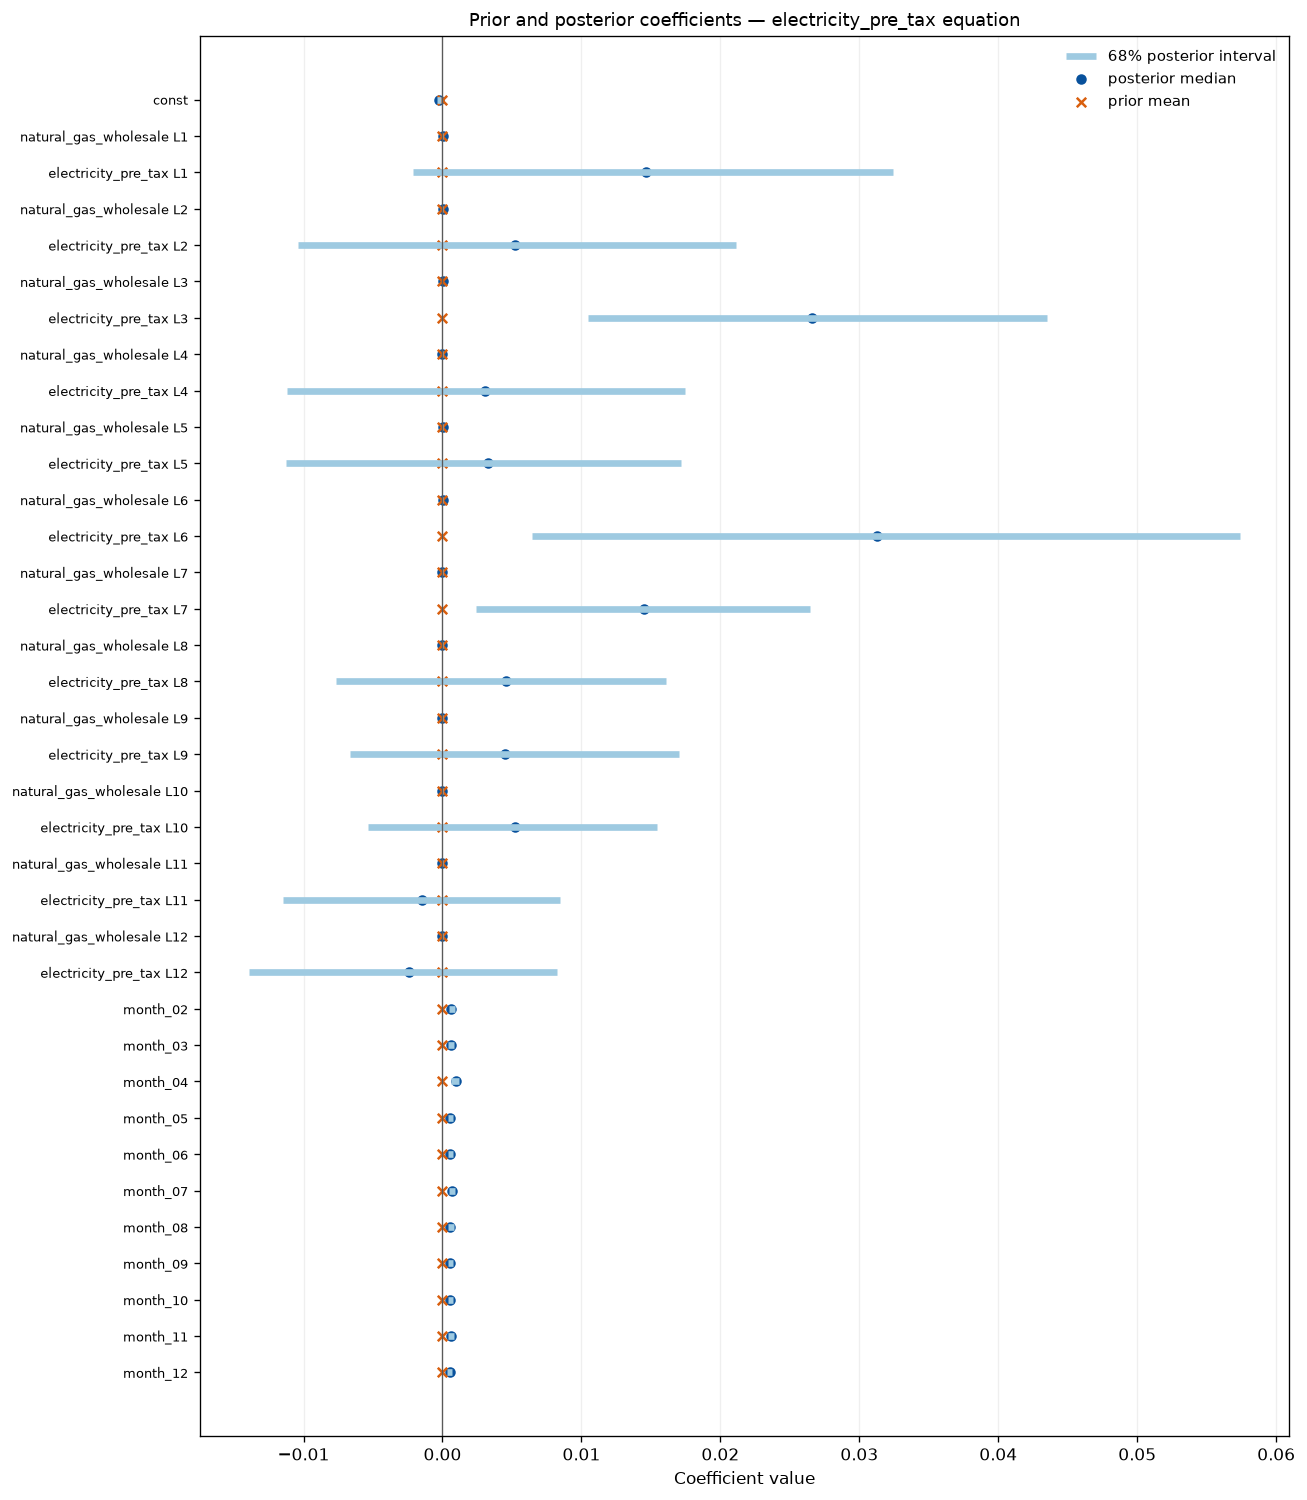

In [6]:
coefficient_tables = coefficient_posterior_tables(result)
for equation in VARIABLES:
    print(f"\n{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

### 6.2 Stochastic volatility and transitory outliers


,,posterior_probability
date,,
2007-01-01,electricity_pre_tax,1.00
2007-07-01,electricity_pre_tax,1.00
2008-01-01,electricity_pre_tax,1.00
2010-01-01,electricity_pre_tax,1.00
2019-01-01,electricity_pre_tax,1.00
2016-01-01,electricity_pre_tax,1.00
2009-01-01,electricity_pre_tax,0.99
2022-01-01,electricity_pre_tax,0.99
2014-01-01,electricity_pre_tax,0.89


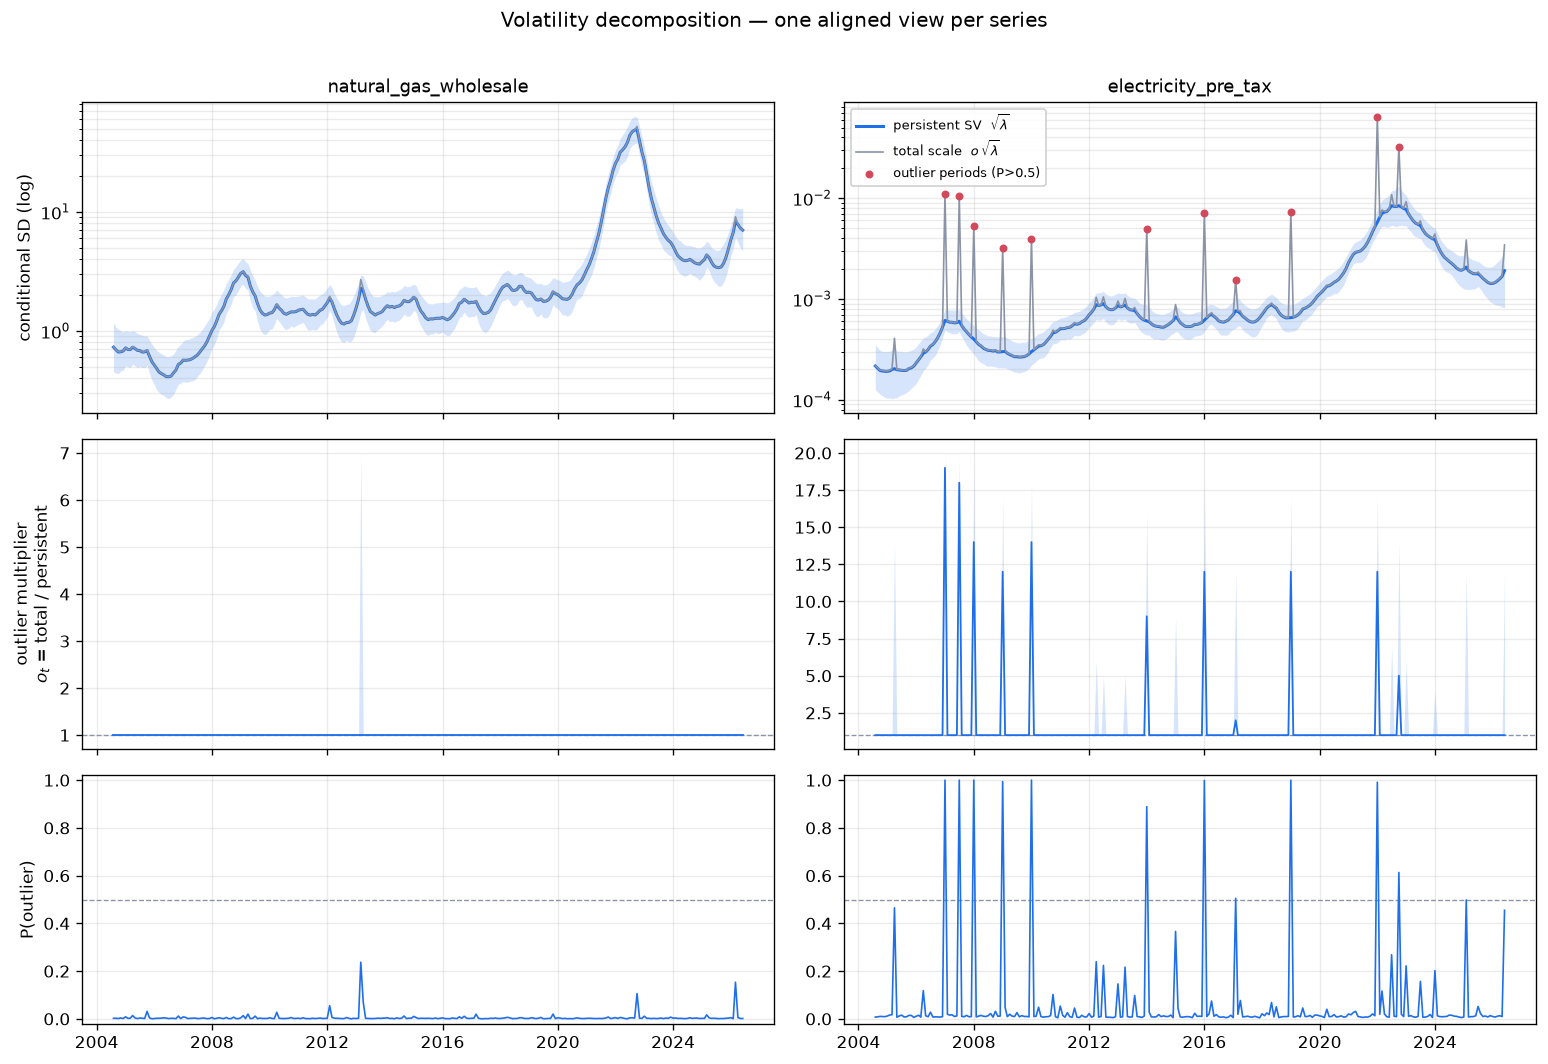

In [7]:
outlier_probability = posterior_outlier_probability(result)
important_outliers = (
    outlier_probability.stack()
    .rename("posterior_probability")
    .loc[lambda series: series >= 0.50]
    .sort_values(ascending=False)
    .to_frame()
)
display(style_numeric_table(
    important_outliers.head(30),
    caption="Dates with posterior outlier probability at least 50%",
))
plot_volatility_decomposition(result)
plt.show()

### 6.3 Standardized structural residuals


,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
natural_gas_wholesale,-3.82 × 10⁻³,0.91,0.06,-0.22,0.01,2.69
electricity_pre_tax,-0.04,0.97,-0.26,0.95,0.04,3.48


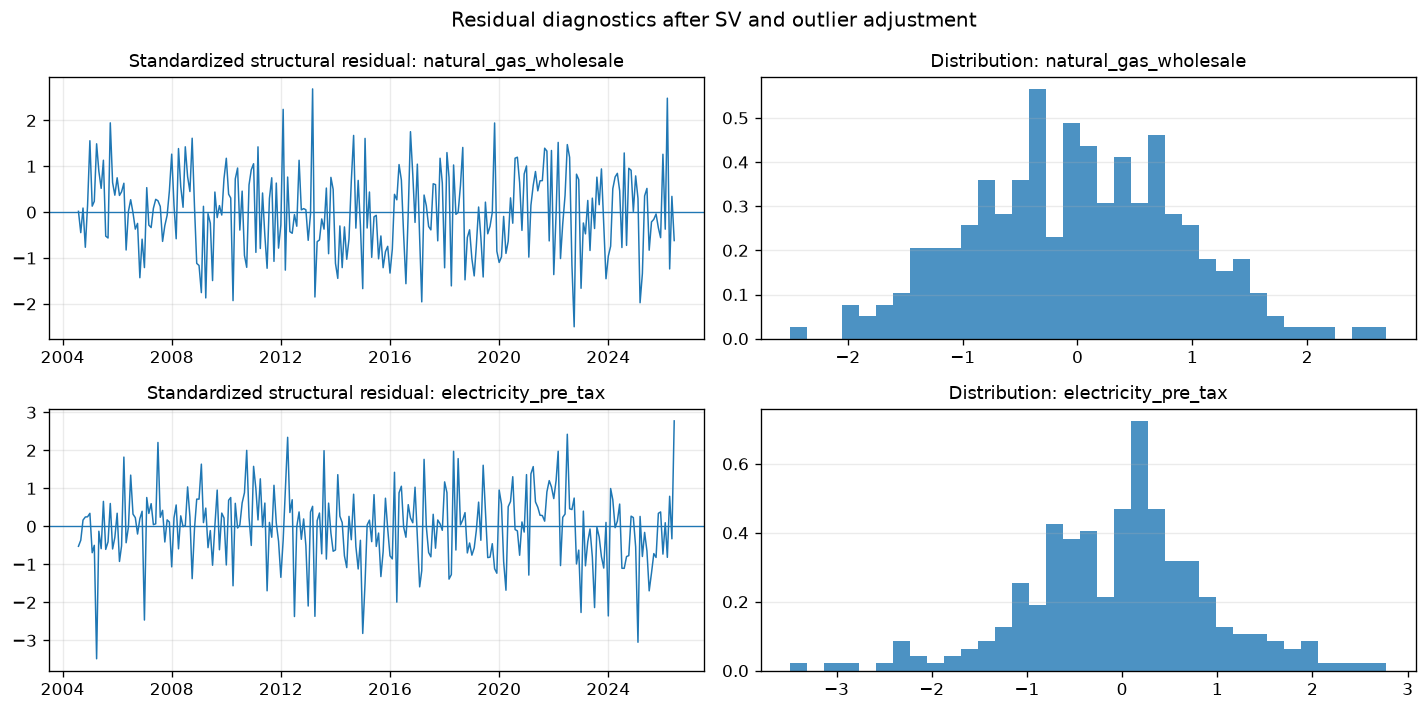

In [8]:
display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

## 7. Ragged-edge nowcast and forecasts


Forecast origin: 2026-08-01
Forecast horizon used: 4 months


,month_02,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11,month_12
date,,,,,,,,,,,
2026-09-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2026-10-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
2026-11-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
2026-12-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-07-01,nowcast,—,0.24,0.24,0.24,0.24,0.25
2026-08-01,nowcast,—,0.23,0.24,0.24,0.24,0.25


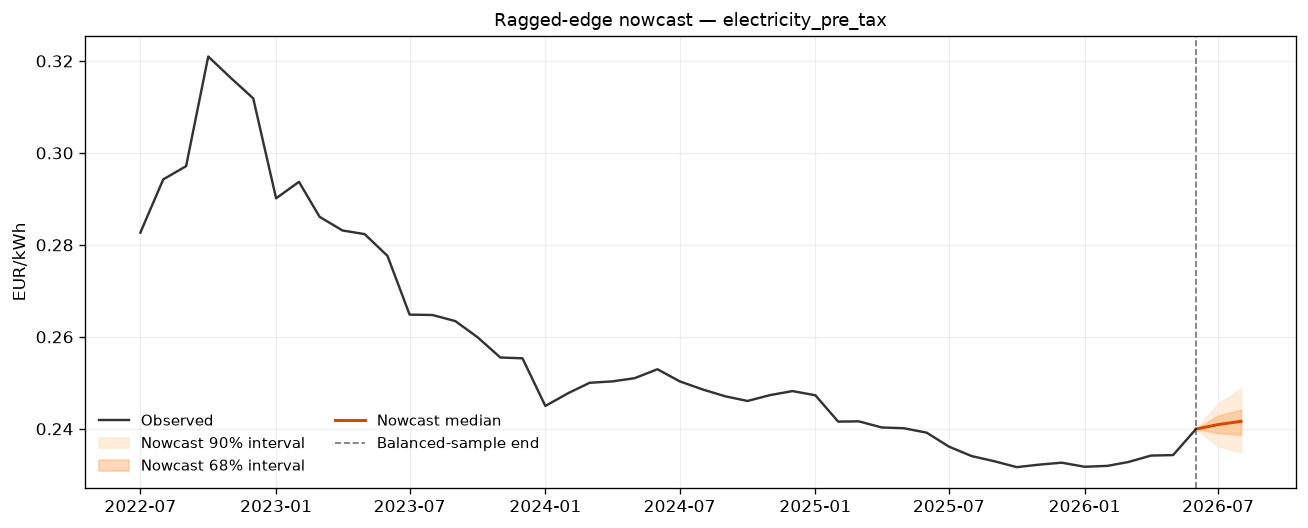

Saved unconditional forecast store: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\results\electricity\20260808\c3570860c0c138880504601e18237299724afdd2698d4ef31f4181ead5b8d22d\forecasts\unconditional


In [9]:
FORECAST_ORIGIN = prep["last_calendar_date"]
MONTHS_TO_YEAR_END = 12 - FORECAST_ORIGIN.month
if MONTHS_TO_YEAR_END == 0:
    MONTHS_TO_YEAR_END = 12
H = max(3, MONTHS_TO_YEAR_END)
FORECAST_DRAWS = min(1_000, result["n_draws"])

future_dates = pd.date_range(
    FORECAST_ORIGIN + pd.offsets.MonthBegin(1),
    periods=H,
    freq="MS",
)
future_seasonal_dummies = make_electricity_seasonal_dummies(
    future_dates,
    reference_month=REFERENCE_MONTH,
)

forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    future_exog=future_seasonal_dummies,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=SIMULATE_FUTURE_OUTLIERS,
    seed=2026,
)

print(f"Forecast origin: {FORECAST_ORIGIN.date()}")
print(f"Forecast horizon used: {H} months")
display(style_numeric_table(
    forecast_unconditional["future_exog"],
    caption="Future seasonal dummies supplied to every posterior forecast draw",
))

nowcast_table = nowcast_summary_table(
    forecast_unconditional,
    observed_levels=levels,
    variable="electricity_pre_tax",
)
if nowcast_table.empty:
    print("No missing electricity_pre_tax observation is present in the ragged edge.")
else:
    display(style_numeric_table(
        nowcast_table,
        caption="Ragged-edge nowcast — electricity_pre_tax",
    ))
plot_nowcast_fan(
    forecast_unconditional,
    historical_levels=levels,
    variable="electricity_pre_tax",
    ylabel=UNITS["electricity_pre_tax"],
)
plt.show()

if SAVE_FORECASTS:
    saved_forecast_paths = save_energy_bvar_forecast_for_result(
        forecast_unconditional,
        result,
        RESULTS_ROOT,
        "unconditional",
    )
    print(f"Saved unconditional forecast store: {saved_forecast_paths['directory']}")


,months_ahead,target_date,q05,q16,median,q84,q95,missing_data_method,missing_treatment_exact
horizon,,,,,,,,,
1 month,1.00,2026-09-01,41.02,48.49,56.25,63.16,70.27,linear,1.00
3 months,3.00,2026-11-01,22.51,42.41,57.26,71.48,86.42,linear,1.00
End of 2026,4.00,2026-12-01,16.43,39.85,56.97,74.95,92.38,linear,1.00


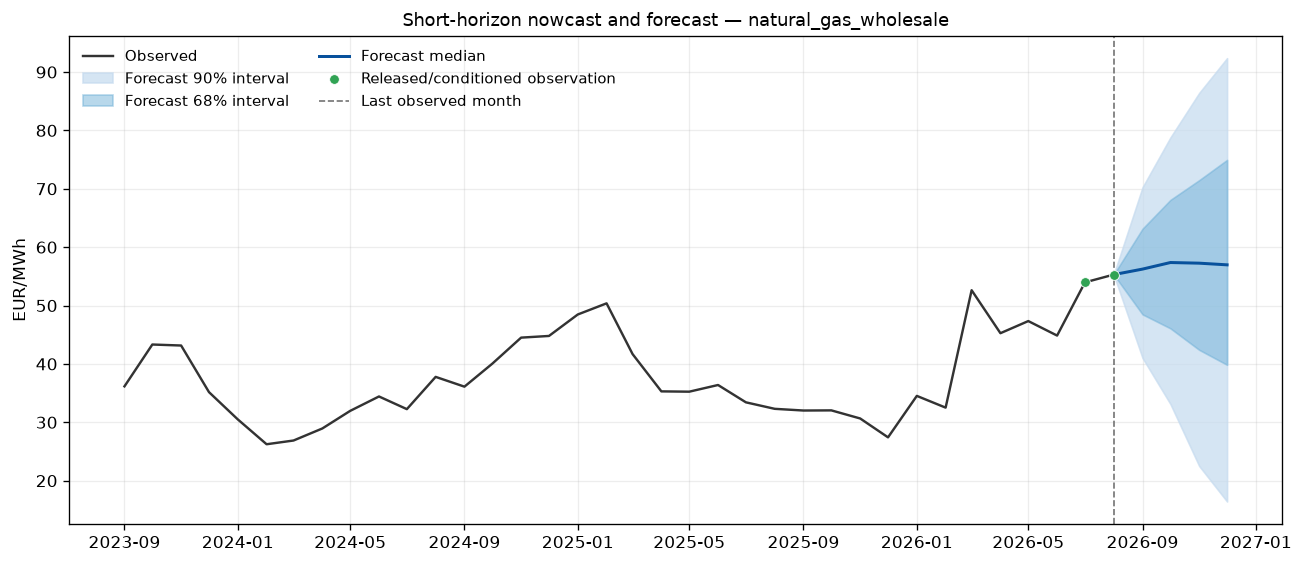

,months_ahead,target_date,q05,q16,median,q84,q95,missing_data_method,missing_treatment_exact
horizon,,,,,,,,,
1 month,1.00,2026-09-01,0.23,0.24,0.24,0.25,0.25,linear,1.00
3 months,3.00,2026-11-01,0.23,0.24,0.24,0.25,0.26,linear,1.00
End of 2026,4.00,2026-12-01,0.22,0.24,0.24,0.25,0.26,linear,1.00


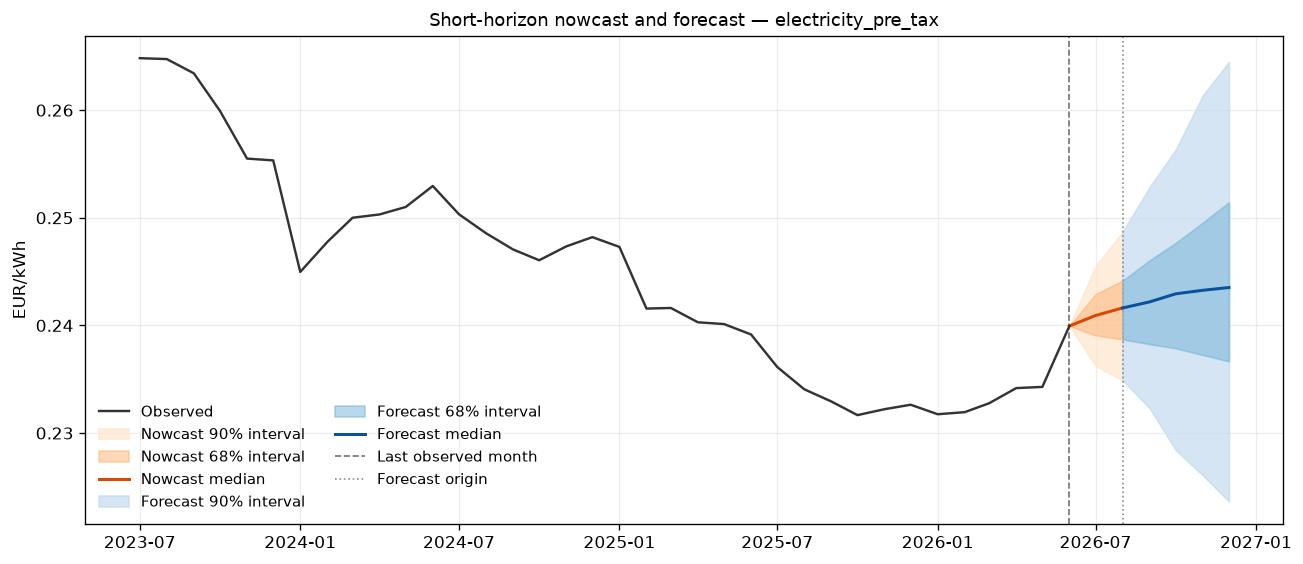

In [10]:
for variable in VARIABLES:
    table = forecast_horizon_table(forecast_unconditional, variable)
    display(style_numeric_table(
        table,
        caption=f"Unconditional level forecast — {variable} ({UNITS[variable]})",
    ))
    plot_short_forecast_fan(
        forecast_unconditional,
        historical_levels=levels,
        variable=variable,
        ylabel=UNITS[variable],
    )
    plt.show()

### 7.1 Conditional wholesale-gas scenario

The future wholesale natural-gas level is fixed at 10% above its latest observed value. Seasonal dummies remain fixed by the calendar and are identical in the unconditional and conditional runs.


Maximum absolute condition error: 2.16 × 10⁻¹²


,months_ahead,target_date,q05,q16,median,q84,q95,missing_data_method,missing_treatment_exact
horizon,,,,,,,,,
1 month,1.00,2026-09-01,0.23,0.24,0.24,0.25,0.25,linear,1.00
3 months,3.00,2026-11-01,0.23,0.24,0.24,0.25,0.26,linear,1.00
End of 2026,4.00,2026-12-01,0.22,0.24,0.24,0.25,0.27,linear,1.00


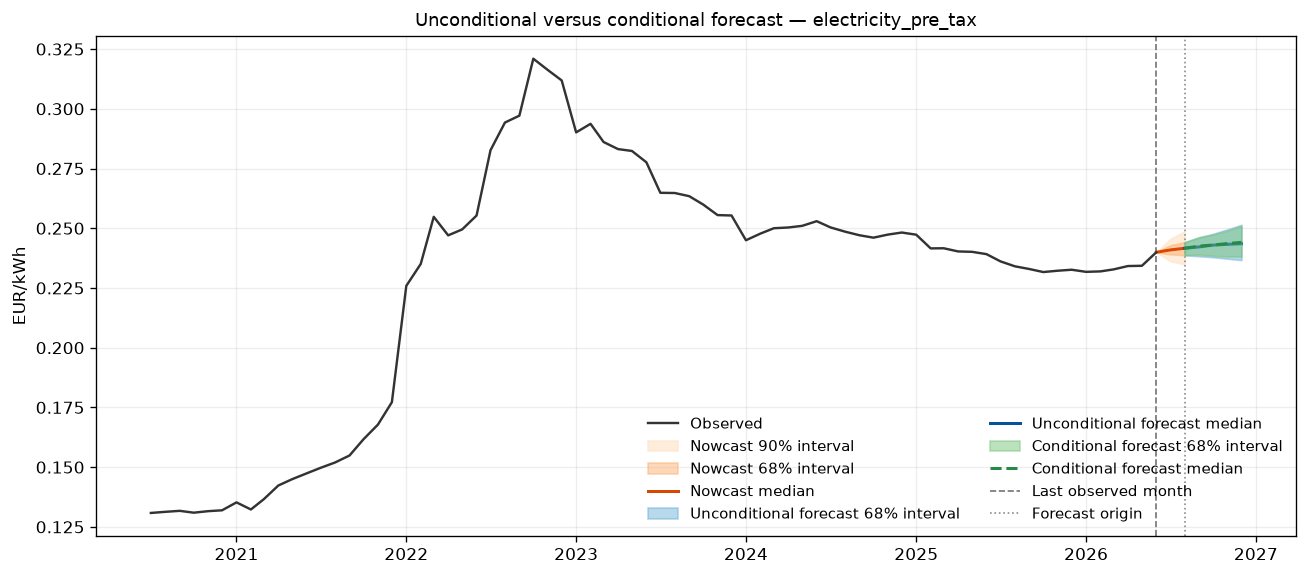

Saved conditional forecast store: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\results\electricity\20260808\c3570860c0c138880504601e18237299724afdd2698d4ef31f4181ead5b8d22d\forecasts\conditional


In [11]:
last_wholesale_level = levels["natural_gas_wholesale"].dropna().iloc[-1]
wholesale_up_10 = np.full(H, 1.10 * last_wholesale_level)

forecast_conditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    level_conditions={"natural_gas_wholesale": wholesale_up_10},
    future_exog=future_seasonal_dummies,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=SIMULATE_FUTURE_OUTLIERS,
    seed=2026,
)

condition_error = np.max(np.abs(
    forecast_conditional["future_level_paths"][:, :, VARIABLES.index("natural_gas_wholesale")]
    - wholesale_up_10[None, :]
))
print(f"Maximum absolute condition error: {format_number(condition_error)}")

display(style_numeric_table(
    forecast_horizon_table(forecast_conditional, "electricity_pre_tax"),
    caption="Conditional electricity_pre_tax forecast (EUR/kWh)",
))
plot_forecast_comparison(
    forecast_unconditional,
    forecast_conditional,
    historical_levels=levels,
    variable="electricity_pre_tax",
    ylabel=UNITS["electricity_pre_tax"],
)
plt.show()

if SAVE_FORECASTS:
    saved_conditional_paths = save_energy_bvar_forecast_for_result(
        forecast_conditional,
        result,
        RESULTS_ROOT,
        "conditional",
    )
    print(f"Saved conditional forecast store: {saved_conditional_paths['directory']}")


## 8. Tax assumptions and inflation impact

The BVAR forecasts the **pre-tax** electricity price. VAT and excise are not endogenous VAR variables: they are re-attributed **ex post**, consistent with the paper's baseline assumption that the latest published tax values are carried forward.

This section separates **assumption from consequence**:

1. validate the historical tax reconstruction and obtain the baseline HICP forecast;
2. show the tax series actually observed/applied historically and the baseline/scenario paths ahead;
3. measure the scenario effect on the consumer-price **level** and on **year-on-year inflation** using the same posterior draws.

For monthly Eurostat taxes, the source publications are semiannual. The assumption figure overlays those raw publication markers on the monthly path produced by the model's six-month expansion rule. A marker off the applied step would therefore reveal a dating problem.


### 8.1 Baseline tax reconstruction and HICP forecast


,value
observations,276.00
maximum_absolute_error,2.84 × 10⁻¹⁴
tolerance,1.00 × 10⁻¹⁰


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,98.74,100.89,102.31,103.71,106.18
3 months,3.00,2026-11-01,96.47,100.53,102.70,104.98,109.26
End of 2026,4.00,2026-12-01,95.59,100.31,102.80,105.67,110.39


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,-0.22,1.95,3.39,4.80,7.29
3 months,3.00,2026-11-01,-2.26,1.85,4.06,6.36,10.70
End of 2026,4.00,2026-12-01,-3.30,1.48,3.99,6.90,11.67


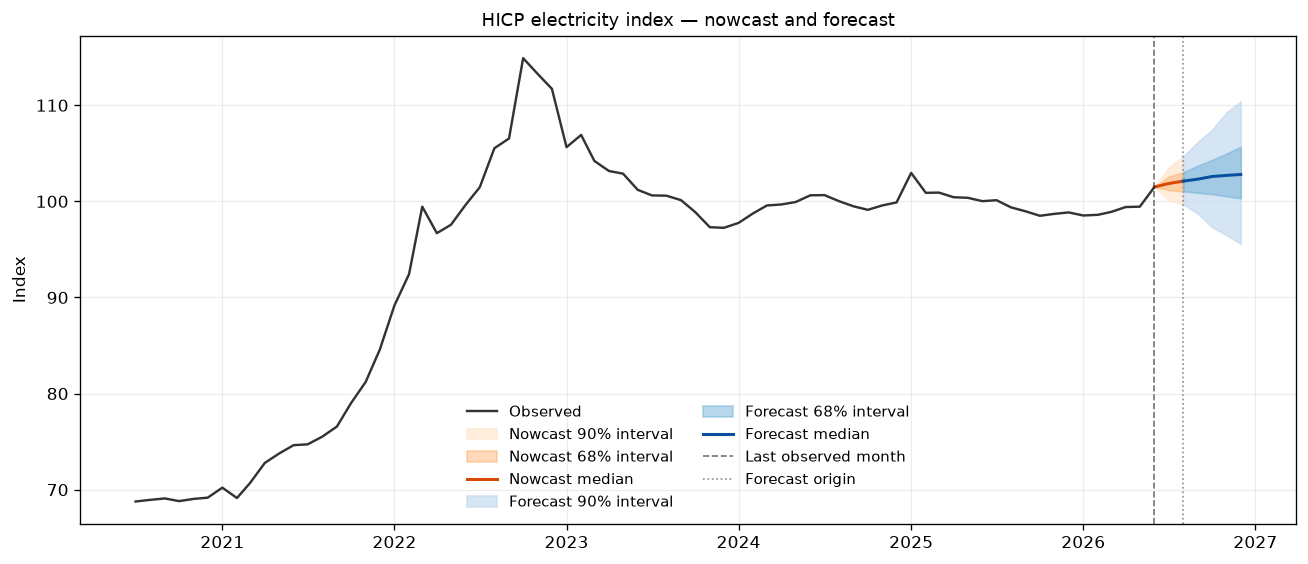

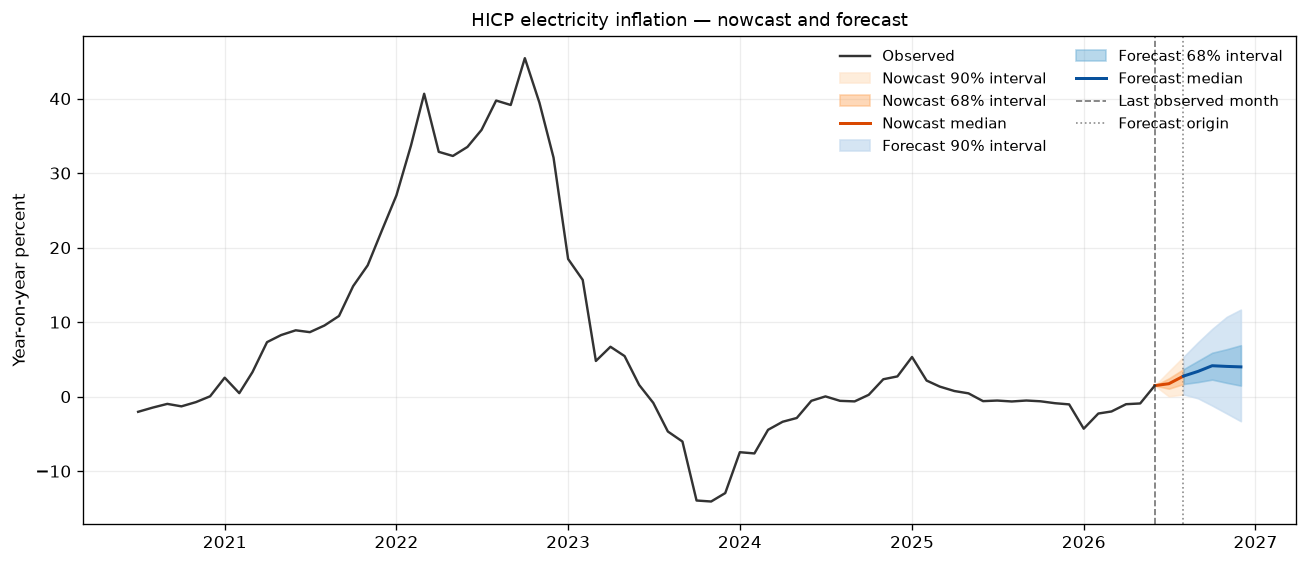

,pre_tax_median,post_tax_median,spread_of_medians_pp,tax_wedge_median_pp,tax_wedge_q16_pp,tax_wedge_q84_pp
date,,,,,,
2026-09-01,3.97,3.39,-0.58,-0.58,-0.83,-0.34
2026-10-01,4.87,4.15,-0.72,-0.72,-1.02,-0.40
2026-11-01,4.76,4.06,-0.70,-0.70,-1.10,-0.32
2026-12-01,4.68,3.99,-0.69,-0.69,-1.19,-0.26


In [12]:
tax_context = load_electricity_tax_context(ELECTRICITY_DATASET)
display(style_numeric_table(
    validate_electricity_tax_round_trip(tax_context).to_frame("value"),
    caption="Electricity tax-construction round-trip check",
))

# Paper baseline: the BVAR forecast is pre-tax; latest published VAT/excise
# are re-attributed ex post and carried forward over the future horizon.
hicp_unconditional = forecast_to_hicp_electricity(
    forecast_unconditional,
    result,
    tax_context,
)

display(style_numeric_table(
    path_horizon_table(
        hicp_unconditional["future_hicp_level_paths"],
        hicp_unconditional["future_dates"],
        forecast_unconditional["last_calendar_date"],
    ),
    caption="HICP electricity index forecast",
))
display(style_numeric_table(
    path_horizon_table(
        hicp_unconditional["future_hicp_yoy_paths"],
        hicp_unconditional["future_dates"],
        forecast_unconditional["last_calendar_date"],
    ),
    caption="HICP electricity year-on-year inflation forecast (%)",
))

plot_hicp_forecast_fan(hicp_unconditional, kind="level", component_label="electricity")
plot_hicp_forecast_fan(hicp_unconditional, kind="yoy", component_label="electricity")
plt.show()

# Baseline accounting wedge, retained as a numerical diagnostic.
display(style_numeric_table(
    tax_inflation_spread_table(hicp_unconditional),
    caption="Baseline tax wedge — post-tax minus pre-tax inflation (pp)",
))


### 8.2 Historical taxes and future assumptions

The figure is intentionally windowed around the policy horizon. VAT is shown in **percent**; a change in VAT is measured in **percentage points**. Excise remains in the same physical price unit as the pre-tax target. The future scenario line is suppressed for any tax instrument that is identical to baseline.


,baseline_vat_percent,scenario_vat_percent,baseline_excise,scenario_excise,scenario_active
date,,,,,
2026-09-01,16.87,17.87,0.04,0.04,1.00
2026-10-01,16.87,17.87,0.04,0.04,1.00
2026-11-01,16.87,17.87,0.04,0.04,1.00
2026-12-01,16.87,17.87,0.04,0.04,1.00


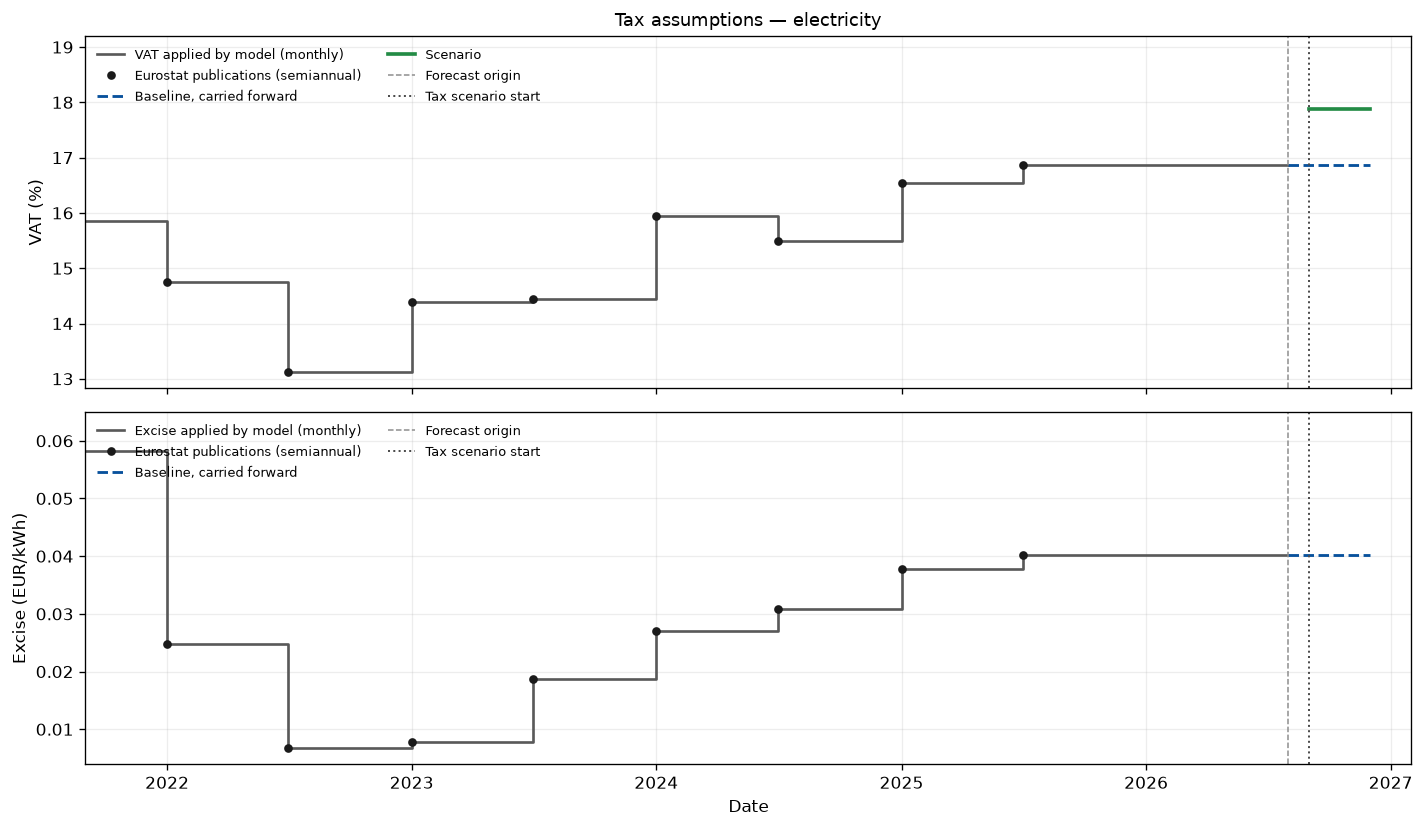

In [13]:
# Illustrative sensitivity: +1 percentage point of VAT from the first forecast month.
# Edit TAX_SCENARIO to impose an announced level/path. Taxes remain ex-post;
# they never enter the BVAR state or coefficient estimation.
TAX_SCENARIO_START = pd.Timestamp(forecast_unconditional["future_dates"][0])
baseline_vat_at_start = float(
    hicp_unconditional["baseline_vat_percent_path"].loc[TAX_SCENARIO_START]
)
TAX_SCENARIO = {
    "start_date": TAX_SCENARIO_START,
    "vat_percent": baseline_vat_at_start + 1.0,
}
# To condition excise too:
# TAX_SCENARIO["excise"] = <level in tax_context["excise_unit"]>
# TAX_SCENARIO["excise_unit"] = tax_context["excise_unit"]

hicp_tax_scenario = forecast_to_hicp_electricity(
    forecast_unconditional,
    result,
    tax_context,
    tax_scenario=TAX_SCENARIO,
)

display(style_numeric_table(
    hicp_tax_scenario["tax_path"].reindex(hicp_tax_scenario["future_dates"]),
    caption="Future tax path — baseline versus scenario",
))

plot_tax_assumptions(
    tax_context,
    hicp_tax_scenario,
    component_label="electricity",
    lookback_years=5,
)
plt.show()


### 8.3 Full-inflation forecast: baseline versus tax scenario

This figure compares the **full consumer-price inflation forecast** under the paper baseline tax assumption with the alternative tax scenario.

Both paths use the **same posterior BVAR pre-tax draws**. The only difference is the ex-post VAT/excise path. The shaded areas are 68% posterior intervals. This view answers the forecasting question — *what does full inflation look like under the alternative tax assumption?* — while Section 8.4 isolates the scenario effect draw by draw.

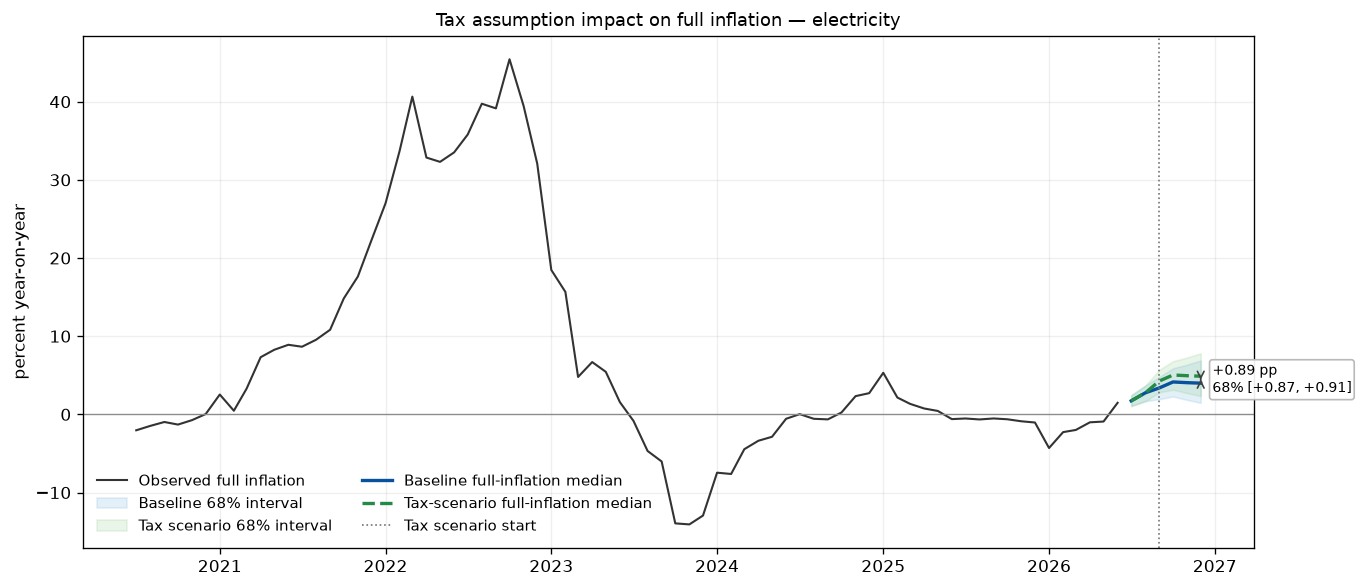

In [14]:
plot_tax_scenario_impact(
    hicp_tax_scenario,
    component_label="electricity",
    show_intervals=True,
    impact_annotations="last",
)
plt.show()


### 8.4 Price-level and YoY inflation effects

The left panel reports the draw-wise relative price-level effect,

$$
100\left(\frac{P_t^{scenario}}{P_t^{baseline}}-1\right),
$$

while the right panel reports the draw-wise inflation effect,

$$
\pi_t^{scenario}-\pi_t^{baseline}.
$$

For a VAT-only step, the level ratio is deterministic conditional on the tax path, so the left panel has no posterior fan. The YoY effect inherits uncertainty from baseline inflation and is temporary because the tax step eventually enters both sides of the year-on-year comparison. If excise is changed instead, the price-level effect generally also inherits posterior uncertainty because the additive excise change is measured relative to the uncertain pre-tax price path.


,periods_ahead,target_date,level_effect_q16_pct,level_effect_median_pct,level_effect_q84_pct,yoy_effect_q16_pp,yoy_effect_median_pp,yoy_effect_q84_pp
horizon,,,,,,,,
1 month,1.00,2026-09-01,0.86,0.86,0.86,0.87,0.88,0.90
3 months,3.00,2026-11-01,0.86,0.86,0.86,0.87,0.89,0.91
end (4 months),4.00,2026-12-01,0.86,0.86,0.86,0.87,0.89,0.91


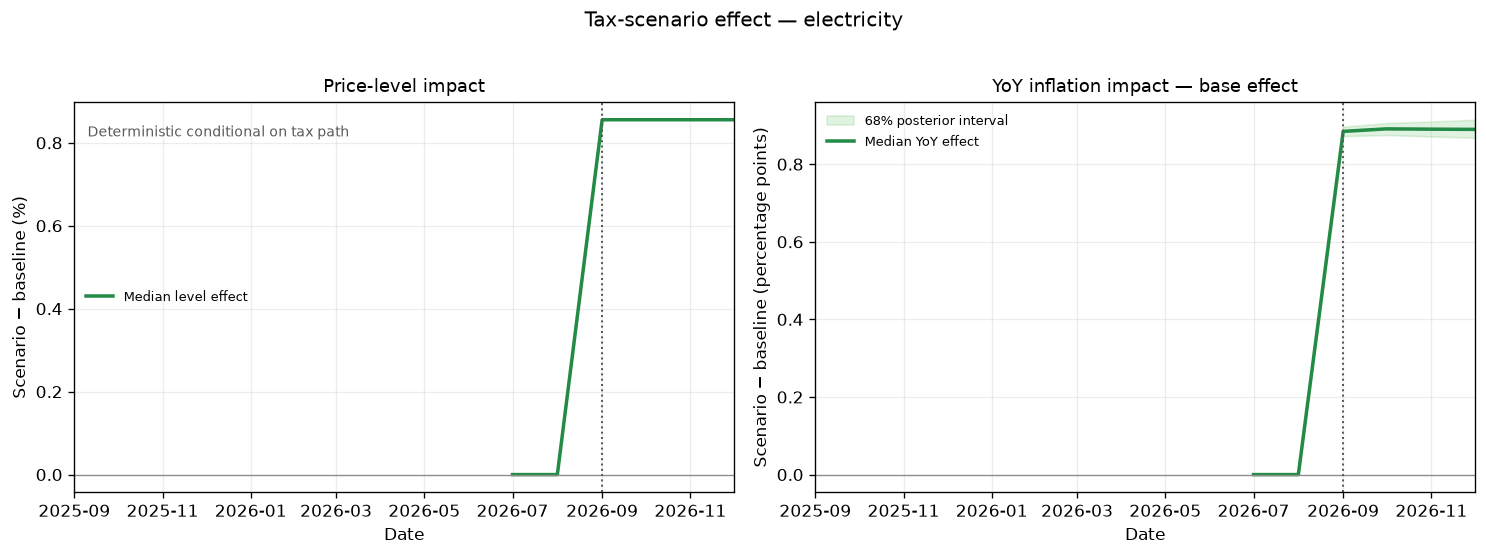

PASS — tax scenario changes only the ex-post tax layer and only from its start date


In [15]:
display(style_numeric_table(
    tax_scenario_effect_summary_table(hicp_tax_scenario),
    caption="Tax-scenario effect — price level (%) and YoY inflation (pp)",
))

plot_tax_level_and_inflation_impact(
    hicp_tax_scenario,
    component_label="electricity",
    lookback_years=1,
)
plt.show()

# Architecture/timing invariants.
np.testing.assert_allclose(
    hicp_tax_scenario["pre_tax_inflation_paths"],
    hicp_unconditional["pre_tax_inflation_paths"],
    rtol=0.0,
    atol=1e-12,
)

dates = pd.DatetimeIndex(hicp_tax_scenario["path_dates"])
before = dates < pd.Timestamp(TAX_SCENARIO_START)
np.testing.assert_allclose(
    hicp_tax_scenario["post_tax_inflation_paths"][:, before],
    hicp_tax_scenario["baseline_post_tax_inflation_paths"][:, before],
    rtol=0.0,
    atol=1e-12,
)

print("PASS — tax scenario changes only the ex-post tax layer and only from its start date")


## 9. Structural analysis

The deterministic seasonal block belongs to the baseline path. It does not alter the companion roots or the impulse propagation matrices. In the historical decomposition, however, the estimated seasonal contribution is included in the reconstructed deterministic base so that the decomposition remains exactly additive.


Recursive identification
Reference date: 2026-06-01
HD maximum reconstruction error: 4.26 × 10⁻¹⁴


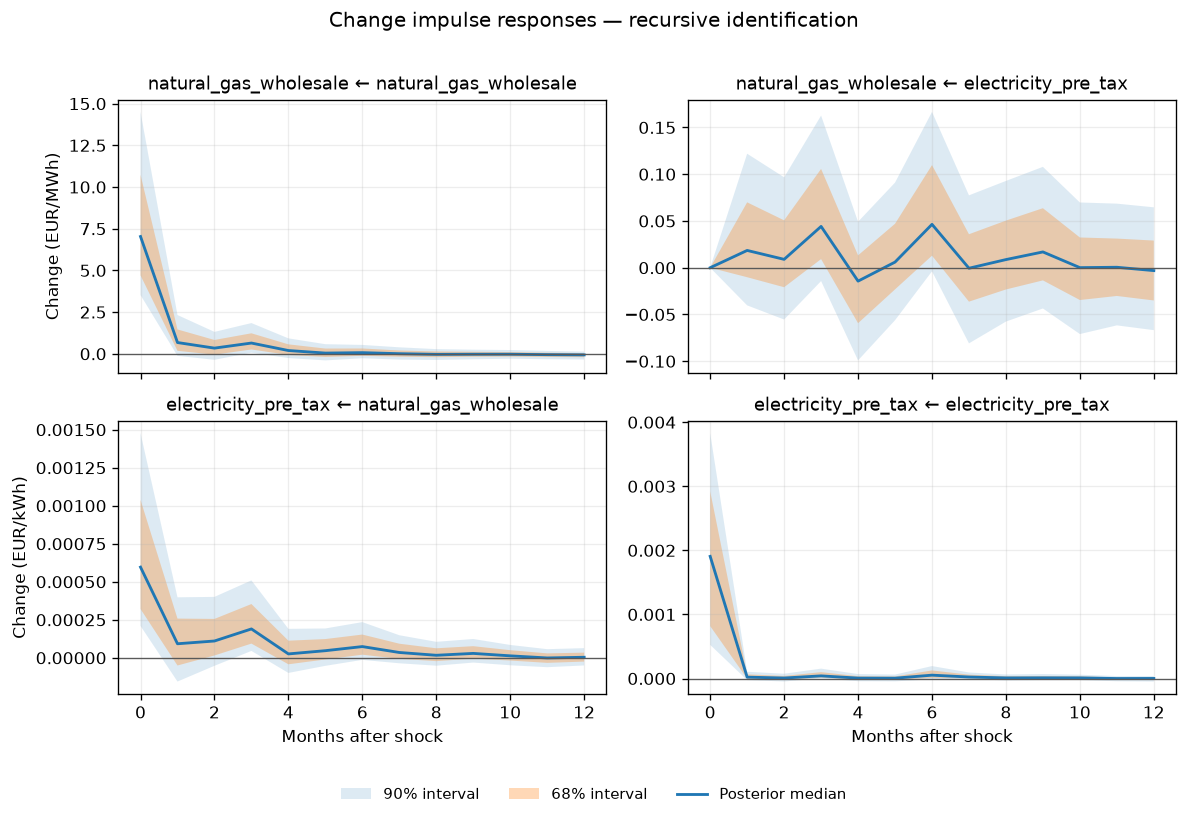

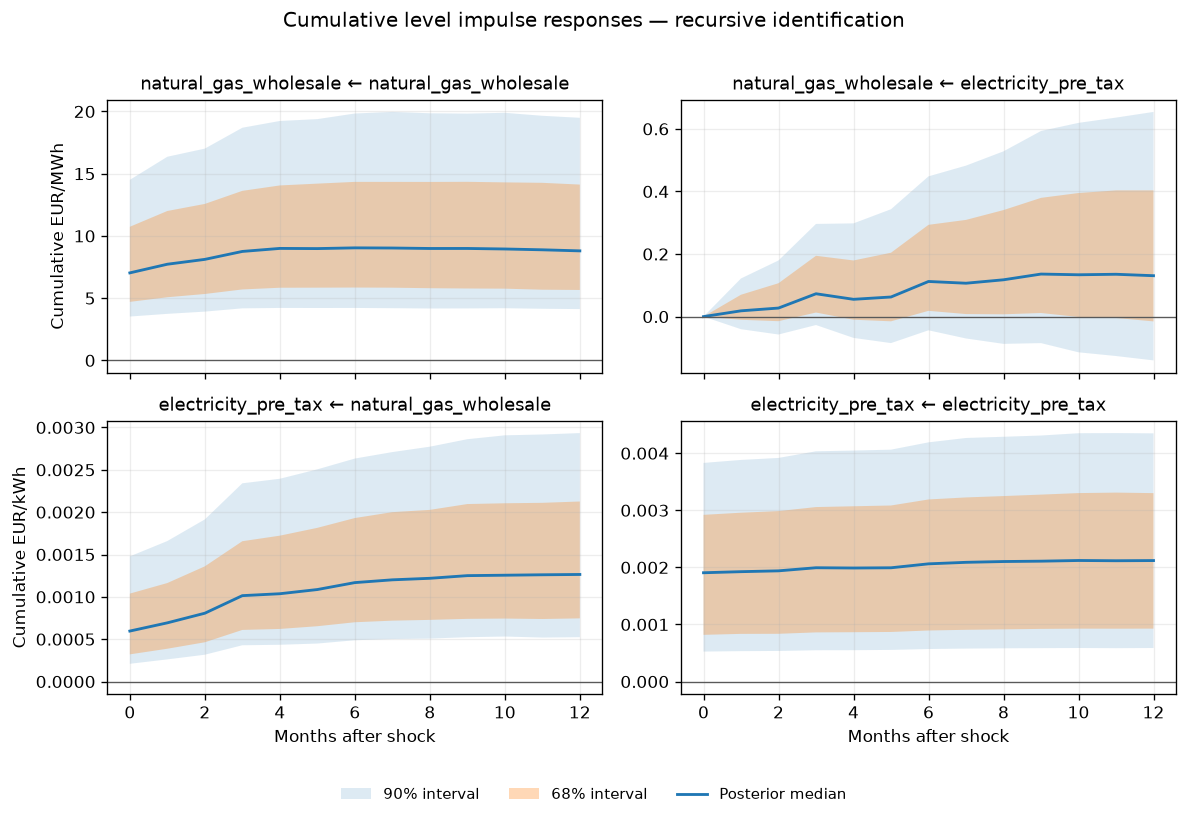

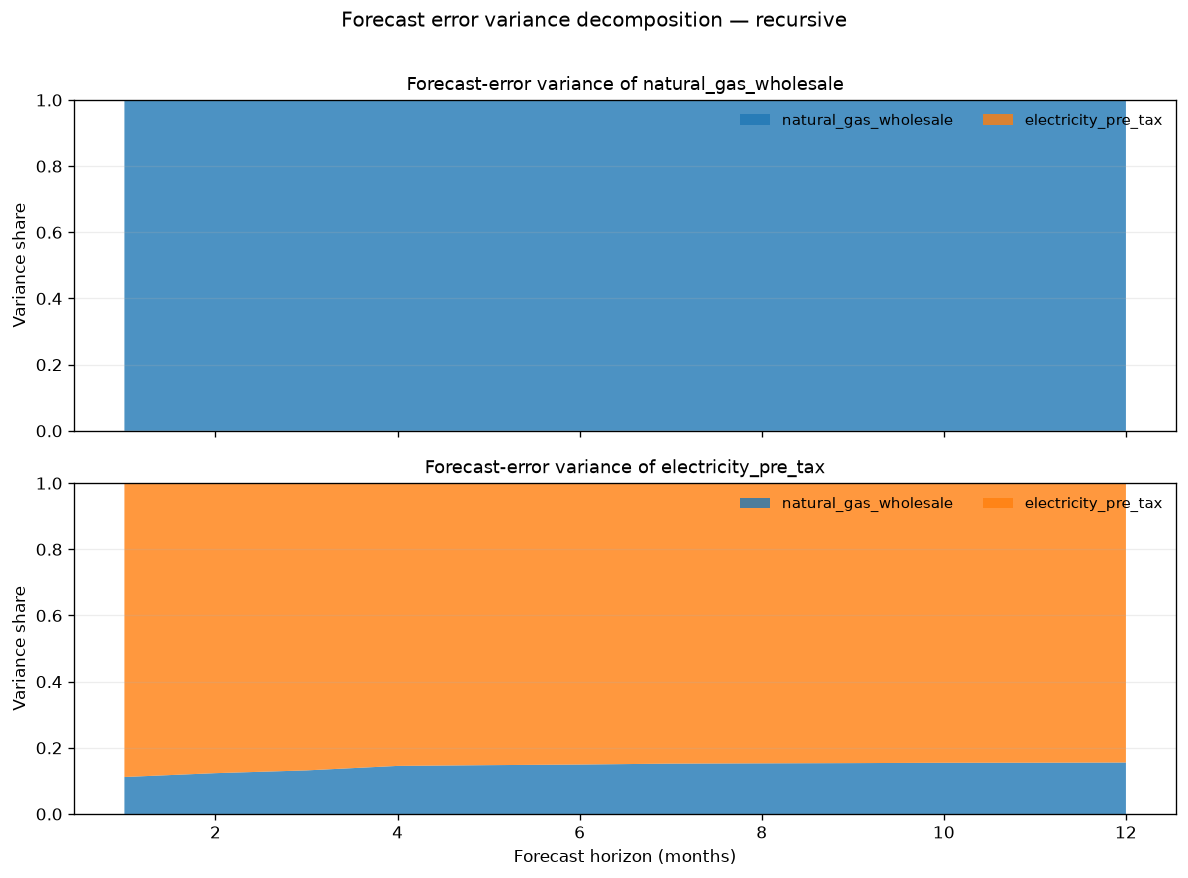

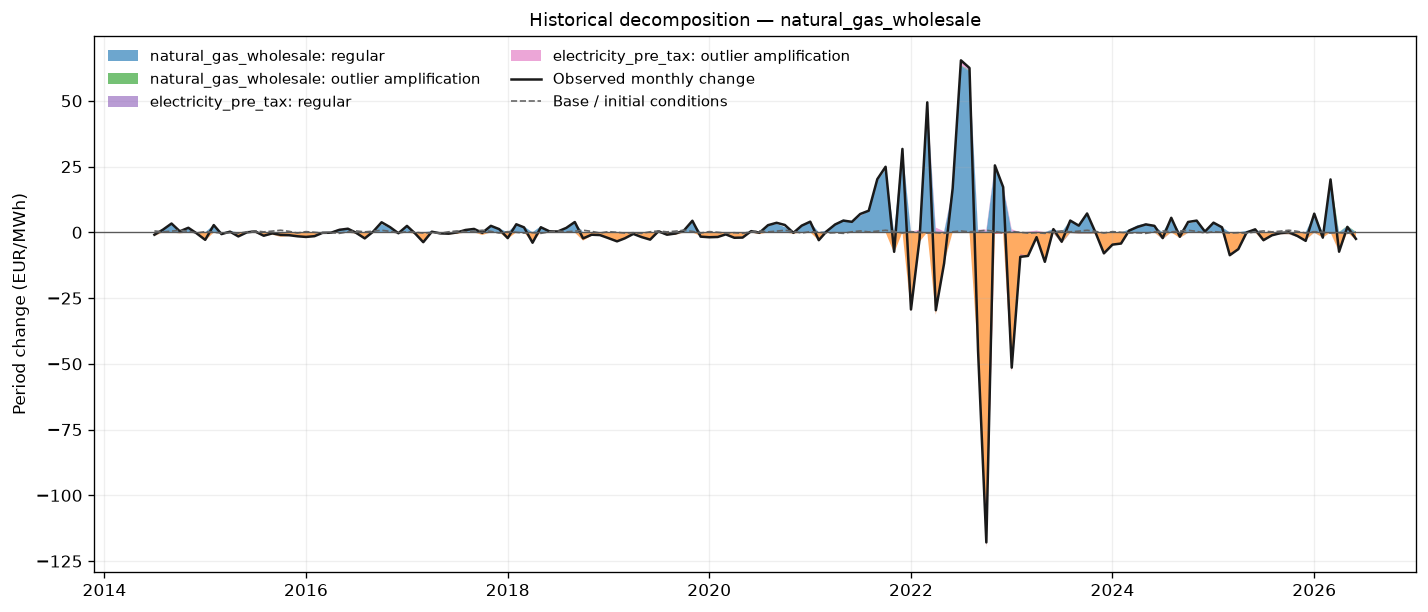

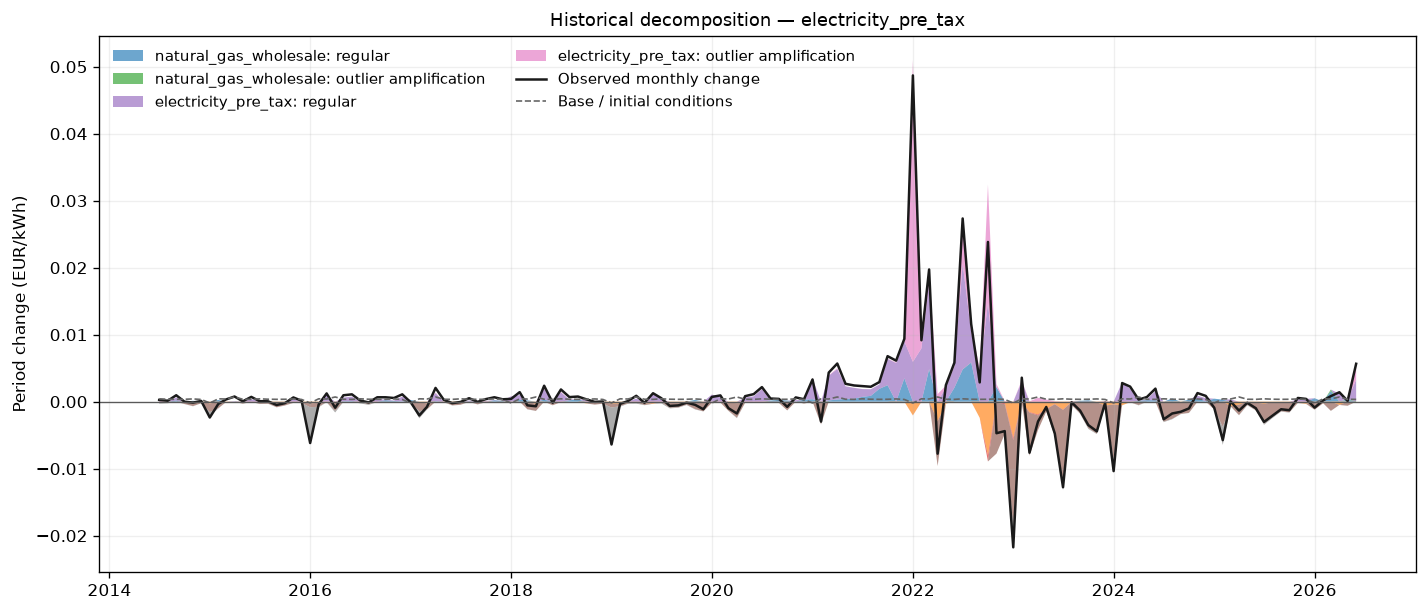


Sign-restricted identification
Accepted posterior-draw share: 100.00%
Mean attempts per accepted draw: 2.32
HD maximum reconstruction error: 4.33 × 10⁻¹³


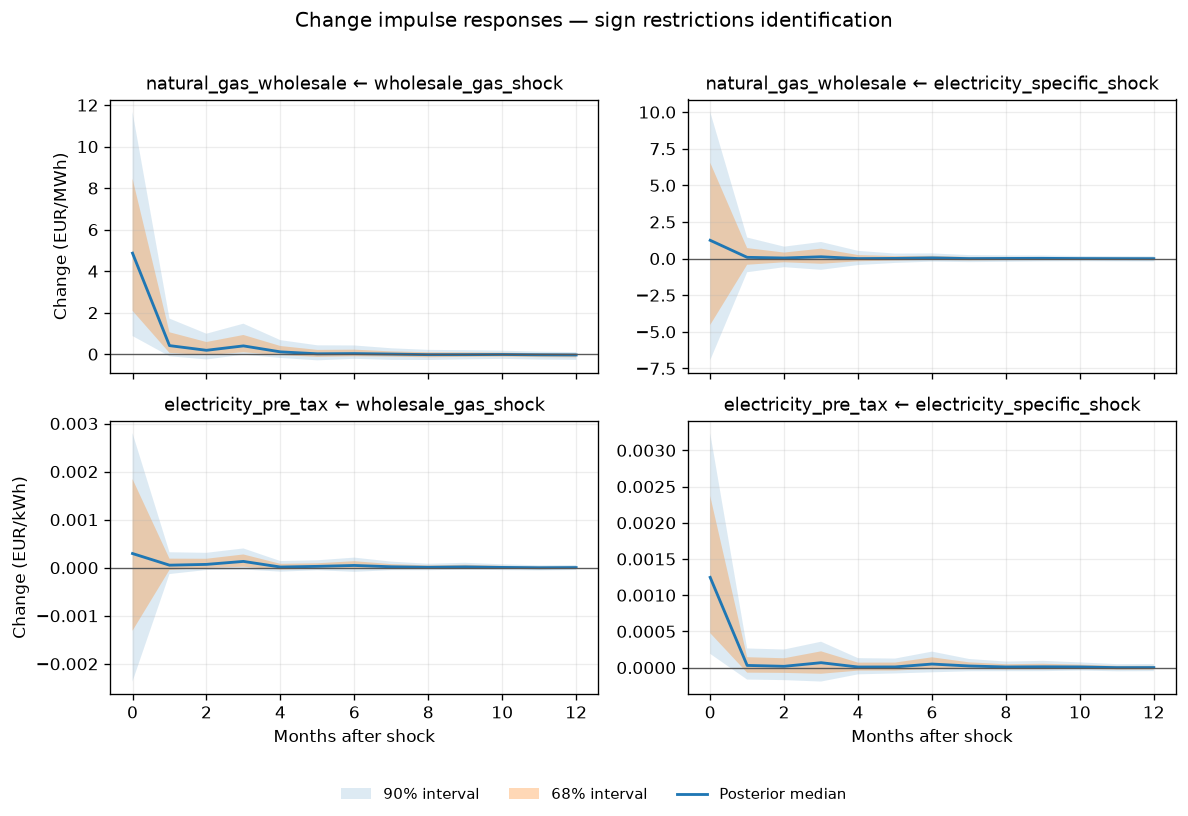

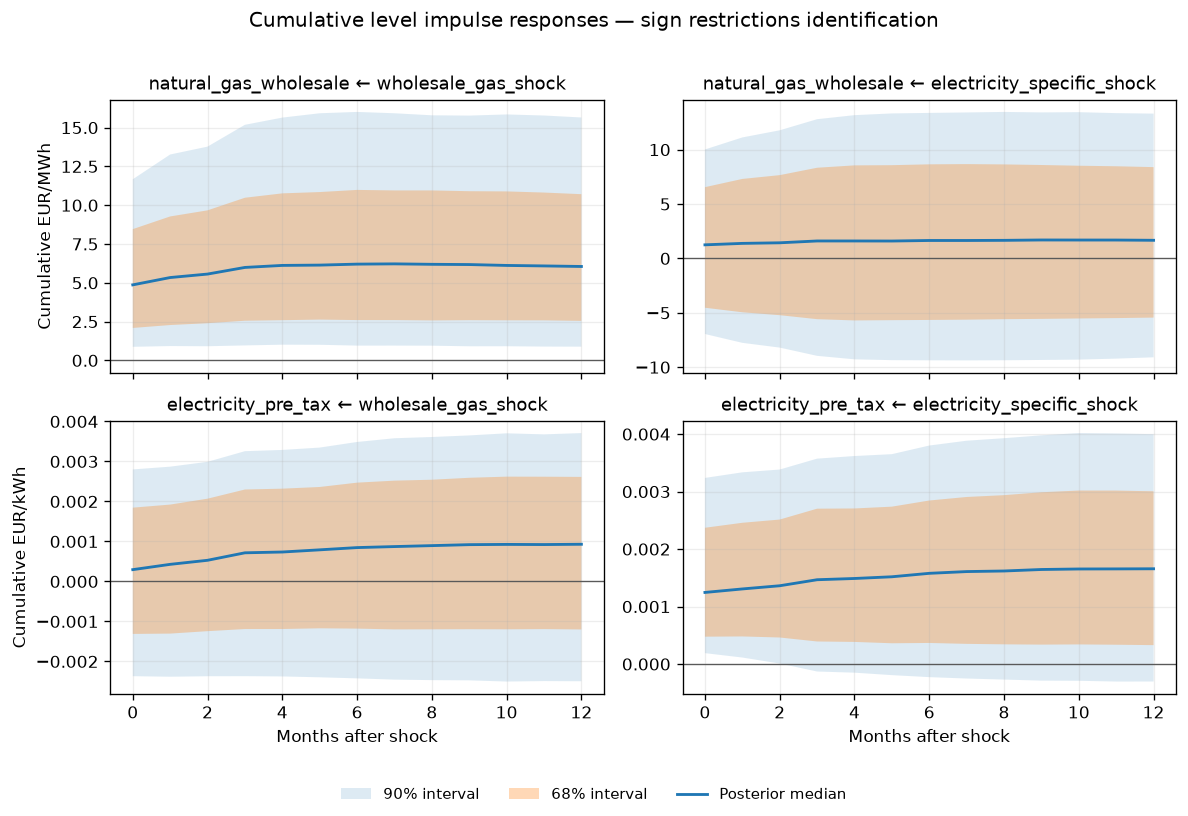

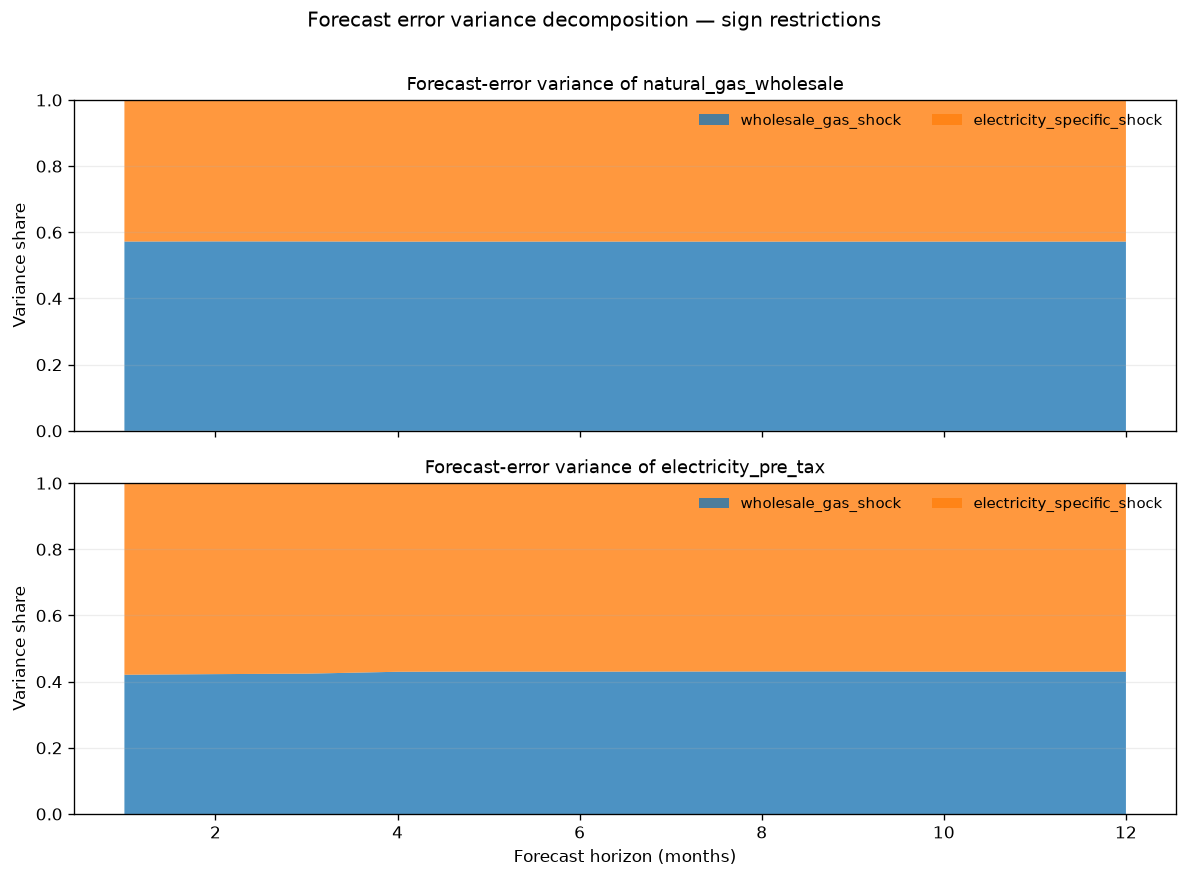

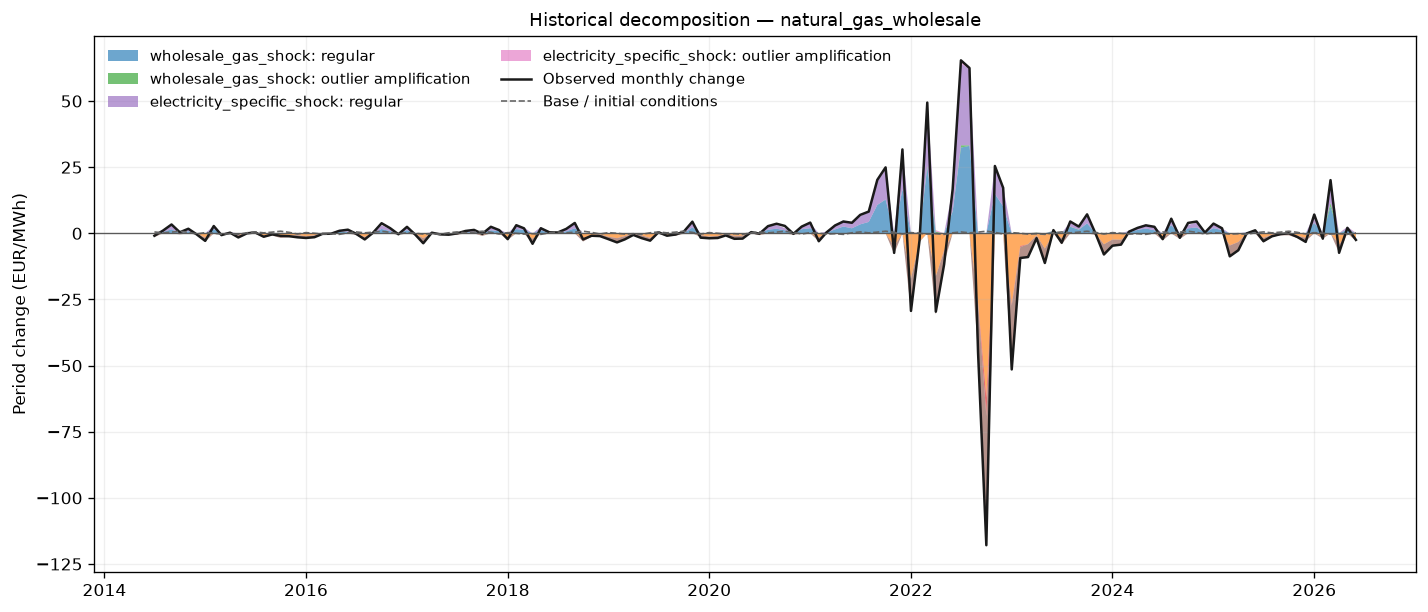

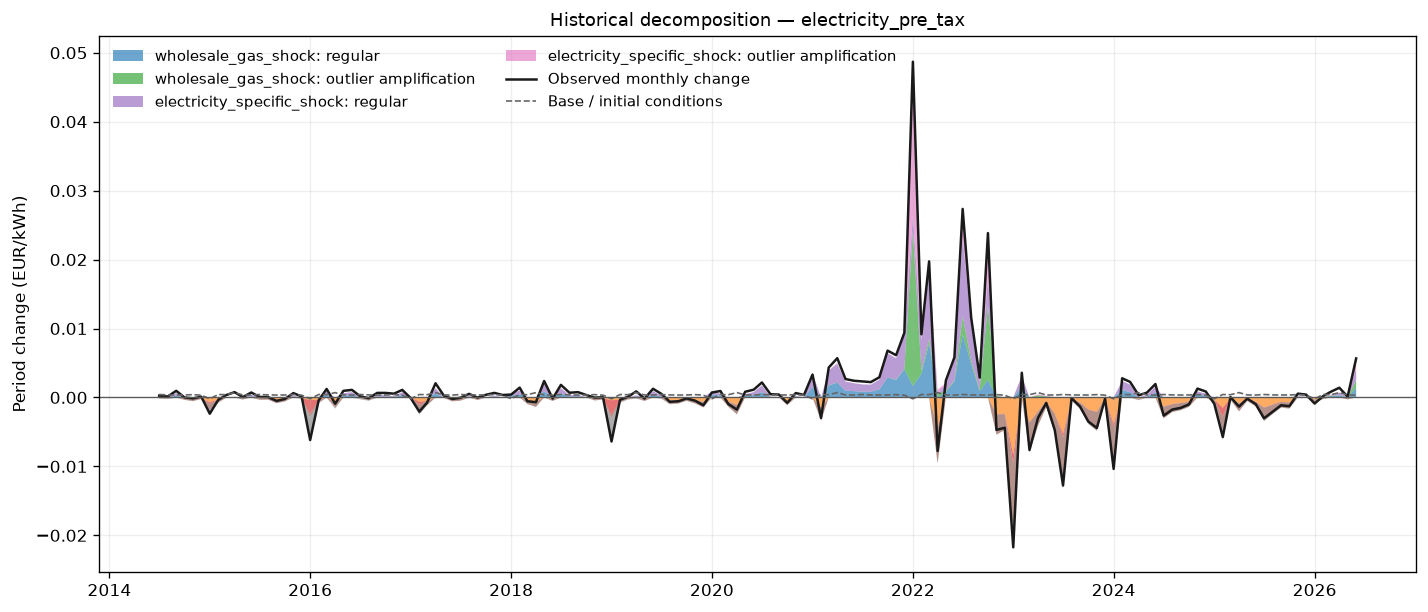

In [16]:
ELECTRICITY_SIGN_RESTRICTIONS = {
    "wholesale_gas_shock": {
        "natural_gas_wholesale": {0: +1},
    },
    "electricity_specific_shock": {
        "electricity_pre_tax": {0: +1},
    },
}

STRUCTURAL_REFERENCE_DATE = prep["balanced_end"]
STRUCTURAL_HORIZON = 12

irf_recursive = impulse_responses(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="structural_std",
    include_outlier_scale=False,
)
fevd_recursive = forecast_error_variance_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
)
hd_recursive = historical_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    split_outlier_amplification=True,
)

print("Recursive identification")
print(f"Reference date: {pd.Timestamp(STRUCTURAL_REFERENCE_DATE).date()}")
print(f"HD maximum reconstruction error: {format_number(hd_recursive['max_reconstruction_error'])}")
plot_impulse_responses(irf_recursive, cumulative=False, units=UNITS)
plot_impulse_responses(irf_recursive, cumulative=True, units=UNITS)
plot_fevd(fevd_recursive)
for response in VARIABLES:
    plot_historical_decomposition(
        hd_recursive,
        response=response,
        last_obs=144,
        unit=UNITS[response],
    )
plt.show()

irf_sign = impulse_responses(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=ELECTRICITY_SIGN_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="structural_std",
    include_outlier_scale=False,
    max_tries=10_000,
    seed=SEED,
)
fevd_sign = forecast_error_variance_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=ELECTRICITY_SIGN_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
    max_tries=10_000,
    seed=SEED,
)
hd_sign = historical_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=ELECTRICITY_SIGN_RESTRICTIONS,
    split_outlier_amplification=True,
    max_tries=10_000,
    seed=SEED,
)

print("\nSign-restricted identification")
print(f"Accepted posterior-draw share: {irf_sign['acceptance_rate']:.2%}")
print(f"Mean attempts per accepted draw: {irf_sign['mean_attempts_per_accepted_draw']:.2f}")
print(f"HD maximum reconstruction error: {format_number(hd_sign['max_reconstruction_error'])}")
plot_impulse_responses(irf_sign, cumulative=False, units=UNITS)
plot_impulse_responses(irf_sign, cumulative=True, units=UNITS)
plot_fevd(fevd_sign)
for response in VARIABLES:
    plot_historical_decomposition(
        hd_sign,
        response=response,
        last_obs=144,
        unit=UNITS[response],
    )
plt.show()

## 10. Diagnosis


### 10.1 Stationarity of transformed endogenous data


In [17]:
stationarity_table = stationarity_tests(prep["balanced"])
display(style_numeric_table(
    stationarity_table,
    caption="Stationarity diagnostics",
))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
natural_gas_wholesale,-4.71,8.17 × 10⁻⁵,15.00,0.04,0.10,25.00,259.00
electricity_pre_tax,-4.33,3.99 × 10⁻⁴,10.00,0.11,0.10,7.00,264.00


### 10.2 MCMC effective sample size and autocorrelation


,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
phi[electricity_pre_tax],0.12,0.06,45.66,8.45 × 10⁻³,0.15
"A[electricity_pre_tax,natural_gas_wholesale]",-8.80 × 10⁻⁵,3.20 × 10⁻⁵,53.07,4.39 × 10⁻⁶,0.14
phi[natural_gas_wholesale],0.20,0.07,75.15,7.64 × 10⁻³,0.12
log likelihood,881.00,14.90,121.62,1.35,0.09
p_outlier[electricity_pre_tax],0.05,0.01,311.54,8.47 × 10⁻⁴,0.06
p_outlier[natural_gas_wholesale],0.01,6.55 × 10⁻³,450.45,3.09 × 10⁻⁴,0.05
own L1[natural_gas_wholesale],0.10,0.07,486.03,3.34 × 10⁻³,0.05
own L1[electricity_pre_tax],0.02,0.02,1604.63,4.49 × 10⁻⁴,0.02
spectral radius,0.78,0.02,2660.65,4.71 × 10⁻⁴,0.02


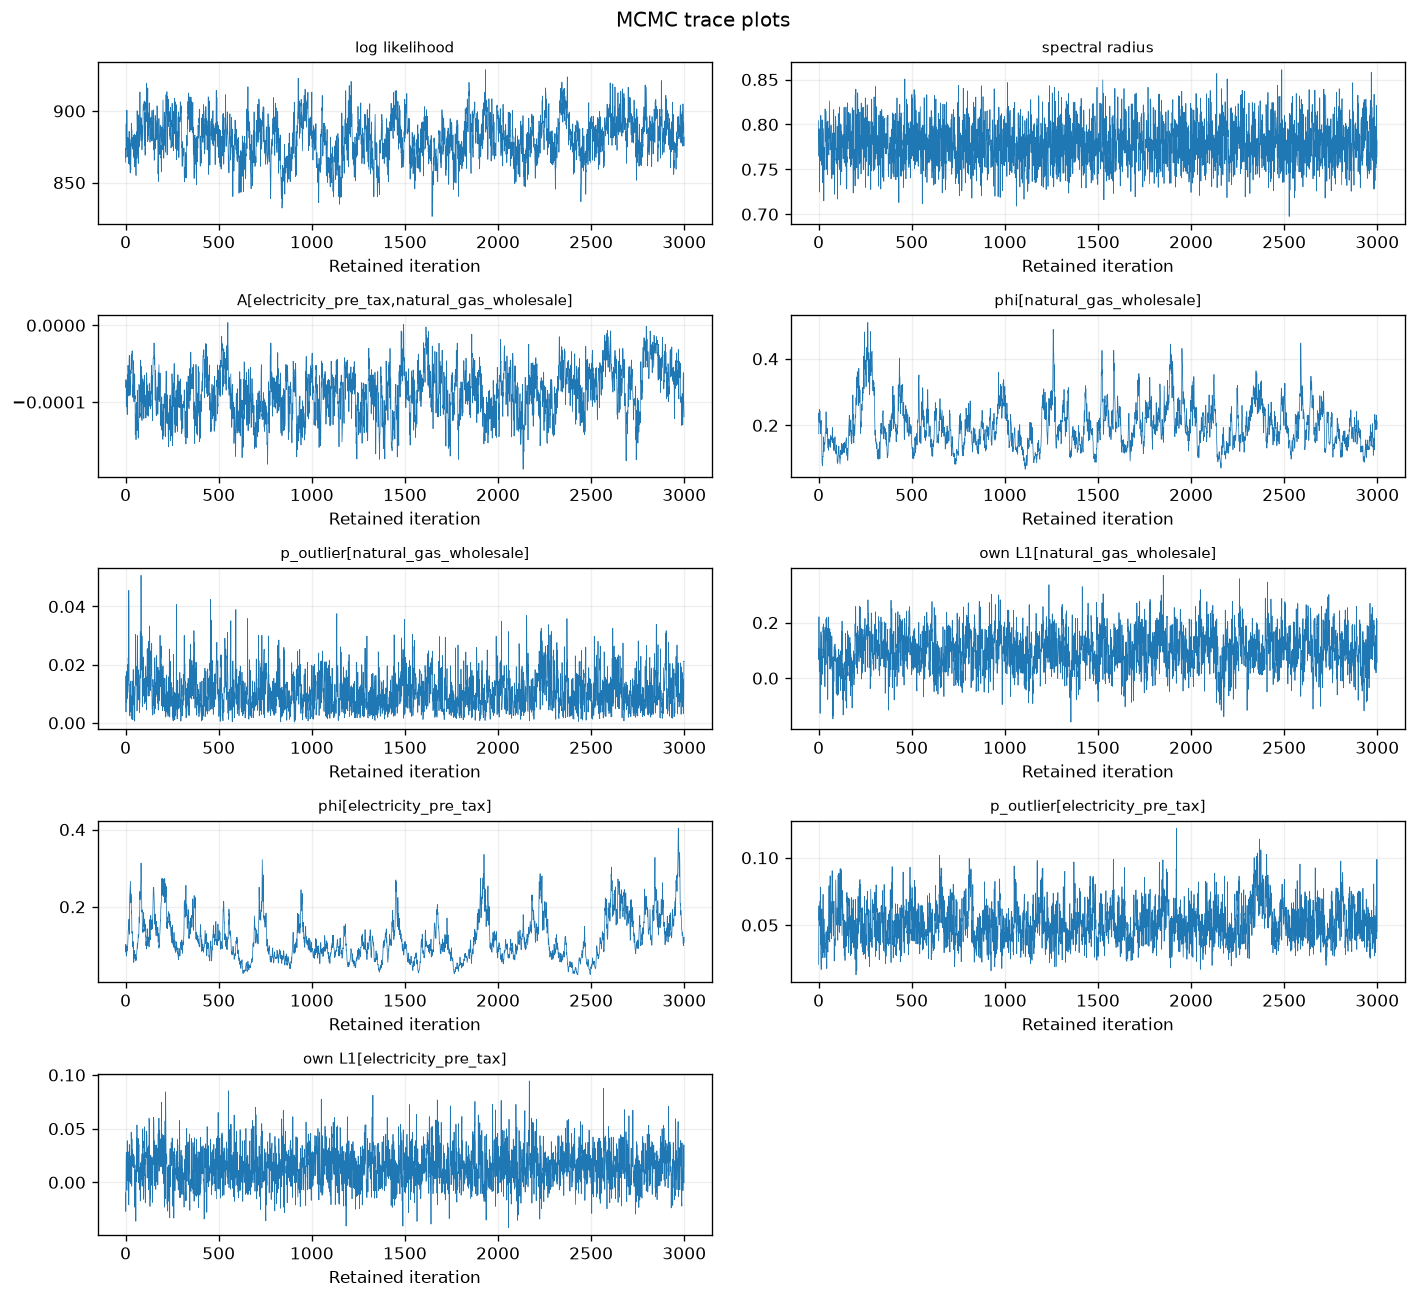

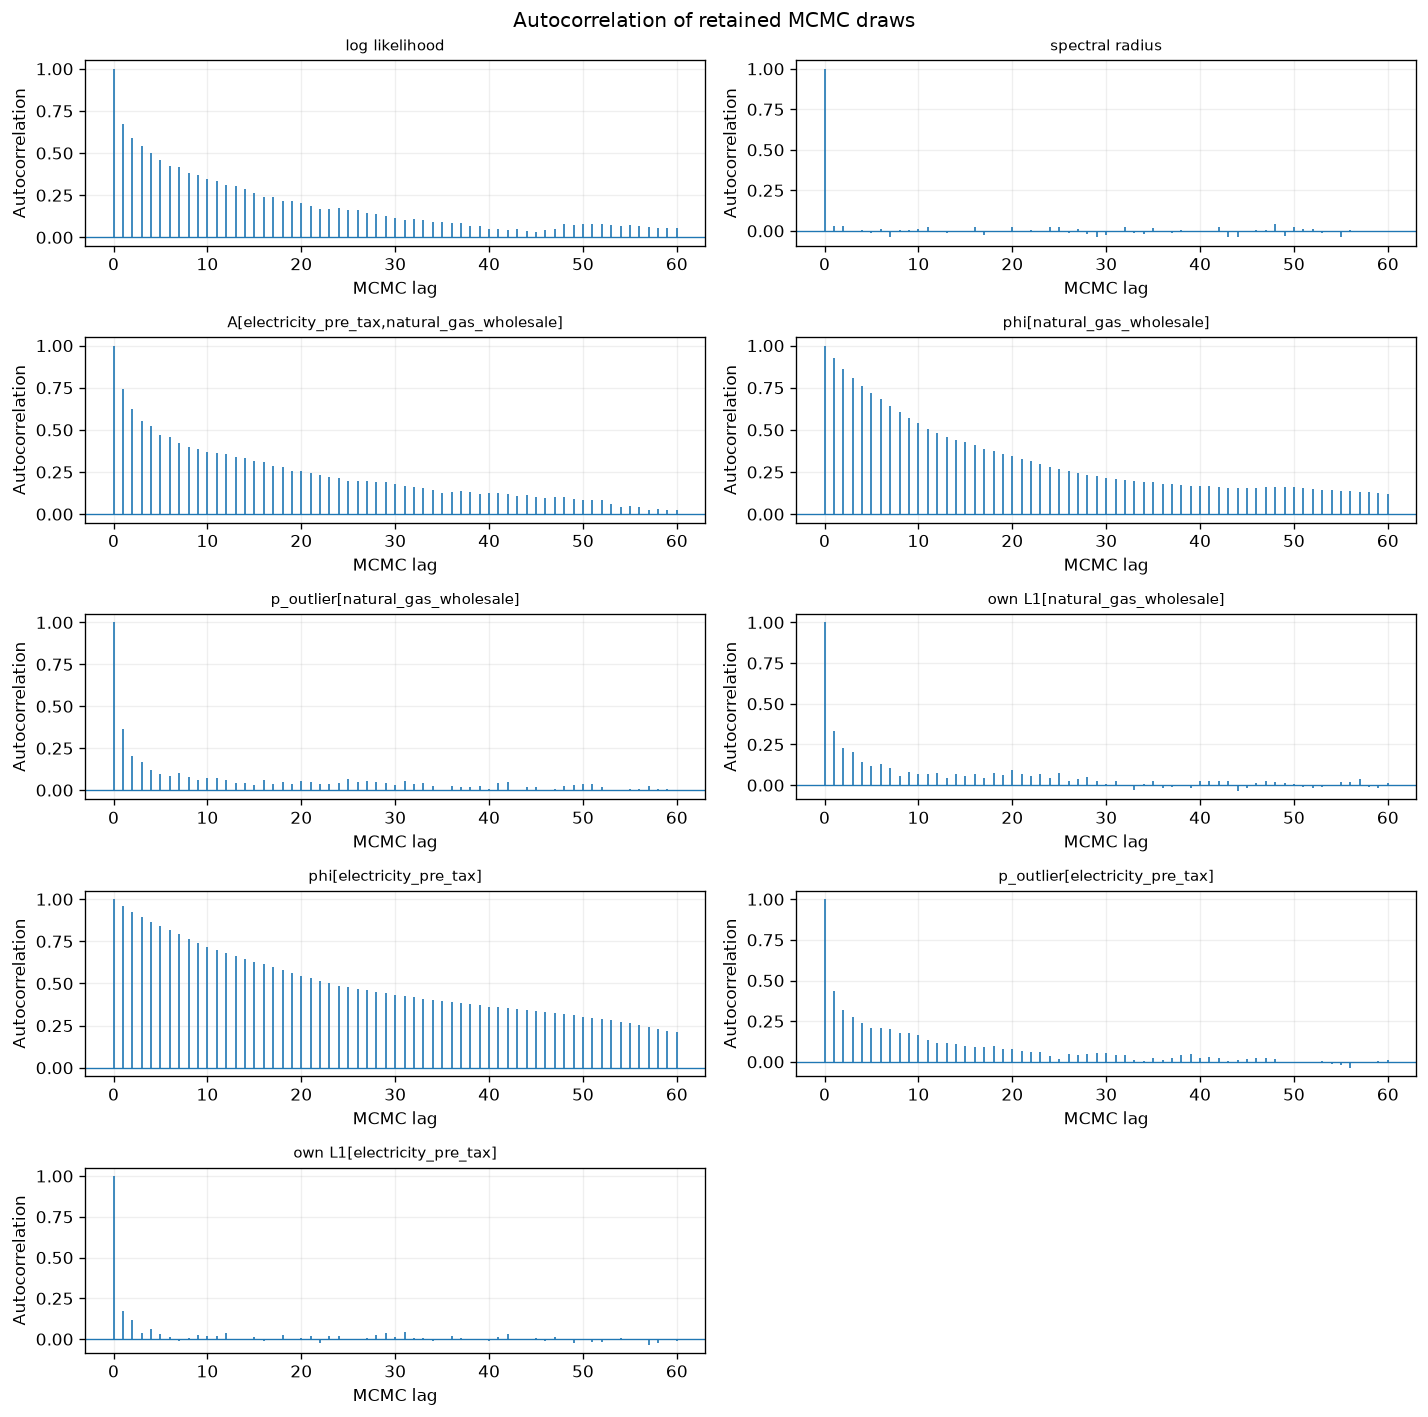

In [18]:
diagnostic_table = mcmc_diagnostics(result)
display(style_numeric_table(
    diagnostic_table.sort_values("ESS"),
    caption="MCMC diagnostics",
))
plot_trace_grid(result)
plot_chain_acf_grid(result, nlags=60)
plt.show()

### 10.3 Stability


,value
retained_draws,3000.00
median_spectral_radius,0.78
q95_spectral_radius,0.82
maximum_spectral_radius,0.86
retained_unstable_share,0.00
B_total_proposals,6000.00
B_unstable_proposals,0.00
B_instability_rejection_rate,0.00


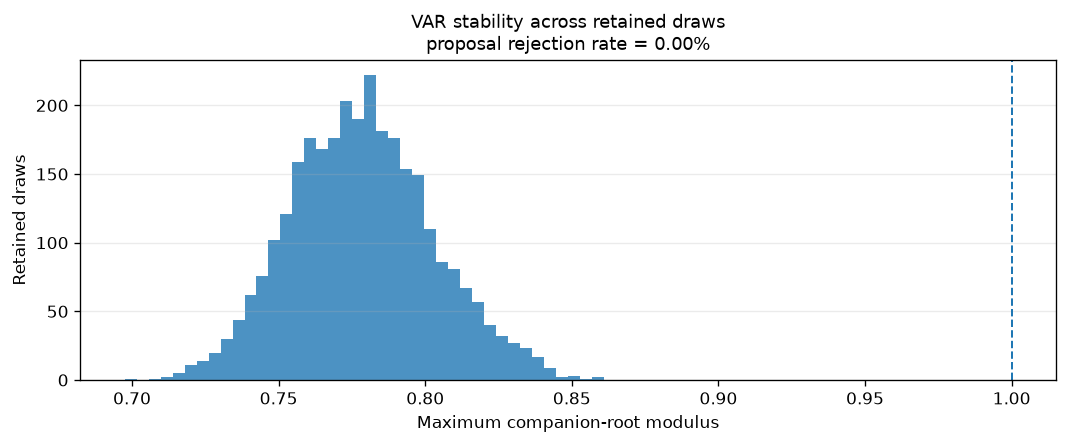

In [19]:
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_spectral_radius(result)
plt.show()

### 10.4 Posterior predictive checks


,observed,replicated_median,replicated_q05,replicated_q95
natural_gas_wholesale: mean,0.13,0.14,-1.32,1.72
natural_gas_wholesale: sd,11.79,10.52,7.15,19.04
natural_gas_wholesale: maximum_absolute,117.89,91.63,52.31,224.21


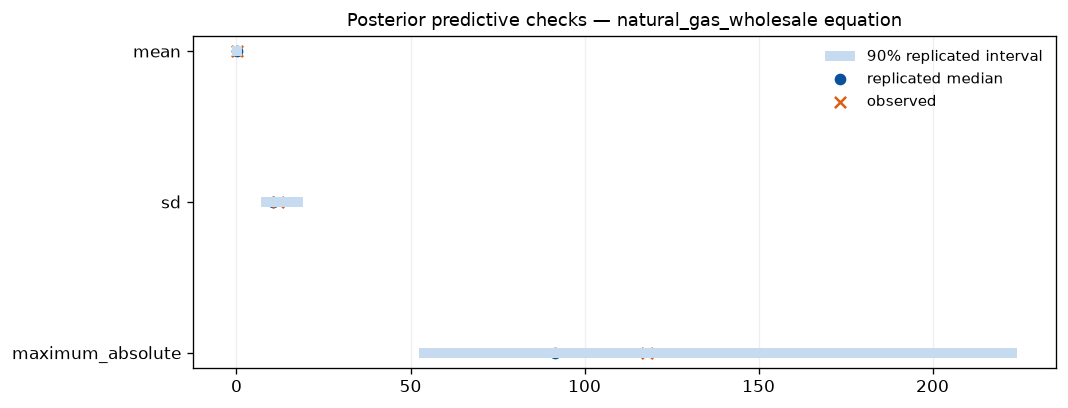

,observed,replicated_median,replicated_q05,replicated_q95
electricity_pre_tax: mean,5.30 × 10⁻⁴,3.27 × 10⁻⁴,-4.62 × 10⁻⁴,1.19 × 10⁻³
electricity_pre_tax: sd,5.27 × 10⁻³,5.72 × 10⁻³,3.41 × 10⁻³,0.01
electricity_pre_tax: maximum_absolute,0.05,0.06,0.02,0.17


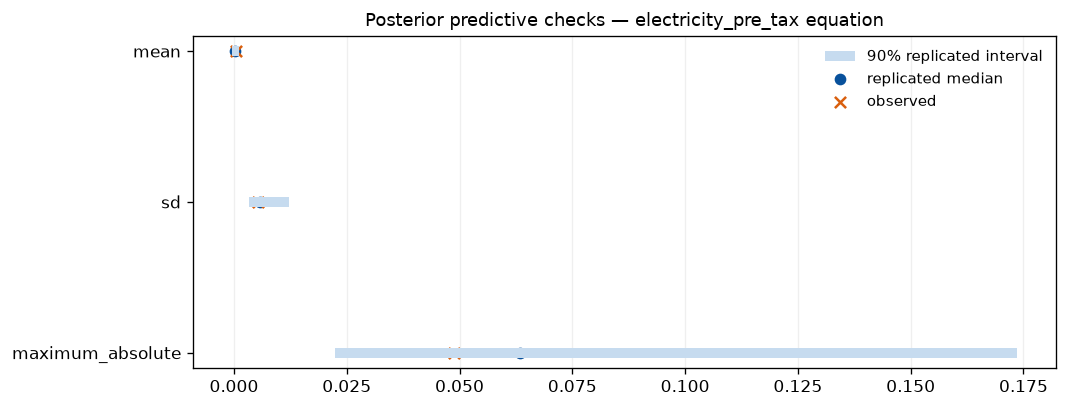

: 

In [ ]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=2027,
)
for equation in VARIABLES:
    equation_rows = ppc_summary.loc[
        [str(index).startswith(f"{equation}:") for index in ppc_summary.index]
    ]
    display(style_numeric_table(
        equation_rows,
        caption=f"Posterior predictive checks — {equation}",
    ))
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

## 11. Validation checklist

Before freezing the electricity model, verify:

* the seasonal design has exactly eleven columns and no collinearity with the constant;
* the gas model remains numerically identical when `exog=None`;
* all future forecasts receive the same calendar-dummy convention as estimation;
* the historical decomposition reconstructs the observed changes within numerical precision;
* the Run ID and saved result directory are retained in the canonical HTML export.
